# Notebook 19 — Flexible Eventless Counterfactual Backgrounds and Target-Specific Event-Weight Robustness

Notebook 19 repeats Exercise 3's eventless background and response-ratio exercise using the frozen flexible-model hierarchy: matched-input linear comparison, Random Forest, Gradient Boosting, MLP, and Transformer. It inherits Notebook 18's target-specific event mapping without rebuilding or reselecting it: R uses realised_model_day and I uses implied_model_day from the frozen 10:00 New York rule. Flexible-model attribution remains predictive reliance, not structural causality.

## A. Execution environment, corrected upstream contract, and regression snapshot

Notebook 18 is the authoritative source for target-specific event days, overlap status, target-date split assignment, and the parametric benchmark. The current N19 outputs are loaded before overwrite only to report realised-side invariance. No TEST result is used to select alignment, models, hyperparameters, epochs, or any calibration threshold.

In [1]:
from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", 140)
torch.set_num_threads(1)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = None

EXECUTION_DEVICE = DEVICE.type
print(f"PyTorch device: {DEVICE}")
if GPU_NAME is not None:
    print(f"GPU: {GPU_NAME}")

ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "Data" / "processed").exists()
)
PROCESSED = ROOT / "Data" / "processed"

def as_bool(value):
    text = str(value).strip().lower()
    assert text in {"true", "false", "1", "0"}
    return text in {"true", "1"}

def read_prior_export(filename, parse_dates=None):
    source = PROCESSED / filename
    return pd.read_csv(source, parse_dates=parse_dates) if source.exists() else pd.DataFrame()

spec_16 = pd.read_csv(PROCESSED / "16_primary_specification.csv").iloc[0]
spec_17 = pd.read_csv(PROCESSED / "17_primary_specification.csv").iloc[0]
spec_18 = pd.read_csv(PROCESSED / "18_primary_specification.csv").iloc[0]
expected_contract = {
    "iv_specification": "WEEKDAY_NORM_IV",
    "iv_column": "iv_model_var",
    "selected_n": 1,
    "selected_m": 12,
    "retain_Q_to_R": False,
    "retain_I_to_R": True,
    "retain_Q_to_I": True,
    "retain_R_to_I": True,
}
for field, expected in expected_contract.items():
    observed = as_bool(spec_16[field]) if isinstance(expected, bool) else spec_16[field]
    observed = int(observed) if isinstance(expected, int) else str(observed)
    assert observed == expected, f"Frozen Notebook 16 contract mismatch: {field}"

assert as_bool(spec_17["exercise_2_complete"])
assert as_bool(spec_18["exercise_3_pipeline_complete"])
assert str(spec_18["event_alignment_version"]) == "TARGET_SPECIFIC_NY_CUT_1000_ET"
assert str(spec_18["alignment_selection_sample"]) == "TRAIN_ONLY"
assert not as_bool(spec_18["bloomberg_snapshot_time_identified"])
assert str(spec_18["iv_specification"]) == "WEEKDAY_NORM_IV"
assert str(spec_18["iv_column"]) == "iv_model_var"
assert int(spec_18["selected_n"]) == 1 and int(spec_18["selected_m"]) == 12
assert as_bool(spec_18["positive_denominator_required"])
assert not as_bool(spec_16["equation_5_implemented"])

panel = pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
panel = panel.sort_values("model_day").reset_index(drop=True)
event_flags = pd.read_csv(PROCESSED / "18_event_day_flags.csv", parse_dates=["model_day"])
target_specific_mapping = pd.read_csv(
    PROCESSED / "18_target_specific_event_mapping.csv",
    parse_dates=["realised_model_day", "implied_model_day", "target_model_day", "model_day"],
)
n18_forecasts = pd.read_csv(PROCESSED / "18_eventless_forecasts.csv", parse_dates=["model_day", "target_model_day"])
n18_coefficients = pd.read_csv(PROCESSED / "18_eventless_coefficients.csv")
n18_event_weights = pd.read_csv(
    PROCESSED / "18_event_response_weights.csv",
    parse_dates=["model_day", "realised_model_day", "implied_model_day", "target_model_day"],
)
n18_pooled_event_weights = pd.read_csv(PROCESSED / "18_pooled_event_weights.csv")
n18_stability = pd.read_csv(PROCESSED / "18_linear_stability_diagnostics.csv")

FROZEN_EVENT_FAMILIES = [
    "FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP"
]
required_mapping_columns = {
    "event_id", "event_label", "event_timestamp_utc", "event_timestamp_ny",
    "realised_model_day", "implied_model_day", "target", "target_model_day",
    "sample_split", "is_clean_single_family", "is_overlap", "family",
}
assert required_mapping_columns.issubset(target_specific_mapping.columns)
assert set(target_specific_mapping["target"]) == {"R", "I"}
assert set(target_specific_mapping["family"]) == set(FROZEN_EVENT_FAMILIES)
assert target_specific_mapping.loc[target_specific_mapping["target"].eq("R"), "target_model_day"].eq(
    target_specific_mapping.loc[target_specific_mapping["target"].eq("R"), "realised_model_day"]
).all()
assert target_specific_mapping.loc[target_specific_mapping["target"].eq("I"), "target_model_day"].eq(
    target_specific_mapping.loc[target_specific_mapping["target"].eq("I"), "implied_model_day"]
).all()
assert set(target_specific_mapping["target_model_day"]).issubset(set(panel["model_day"]))

prior_selected_hyperparameters = read_prior_export("19_selected_hyperparameters.csv")
prior_test_forecasts = read_prior_export("19_forecasts_test.csv", ["model_day"])
prior_validation_forecasts = read_prior_export("19_forecasts_validation.csv", ["model_day"])
prior_event_weights = read_prior_export("19_event_response_weights.csv", ["model_day"])
prior_test_metrics = read_prior_export("19_test_background_comparison.csv")
print("Corrected Notebook 18 target-specific alignment contract loaded.")

PyTorch device: cuda
GPU: NVIDIA GeForce RTX 5070
Corrected Notebook 18 target-specific alignment contract loaded.


## C. Common 12-day candidate information set and target-specific masks

All models retain the frozen chronological feature order: lag 12 through lag 1, with Q/R/I within each lag. The 36 features are constructed on the intact panel before the target-specific N18 masks are joined. R masks realised event days; I masks implied event days.

In [2]:
# Construct all complete 36-lag histories before applying corrected target-specific masks.
panel["Q"] = pd.to_numeric(panel["squared_return"])
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"])
panel["I"] = pd.to_numeric(panel["iv_model_var"])
state_snapshot = panel[["model_day", "Q", "R", "I"]].copy()

FEATURES = [
    f"{state}_lag{lag}"
    for lag in range(12, 0, -1)
    for state in ["Q", "R", "I"]
]
expected_feature_order = tuple(FEATURES)
for state in "QRI":
    for lag in range(1, 13):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)

lag_snapshot = panel[["model_day", *FEATURES]].copy()
panel = panel.merge(event_flags, on="model_day", how="left", validate="one_to_one")
for target in "RI":
    for suffix in [
        "is_target_event_day", "is_clean_single_family", "is_overlap",
    ]:
        column = f"{target}_{suffix}"
        assert column in panel.columns
        panel[column] = panel[column].eq(True)
    for suffix in ["n_target_occurrences", "n_target_families"]:
        column = f"{target}_{suffix}"
        panel[column] = pd.to_numeric(panel[column], errors="coerce").fillna(0).astype(int)
    panel[f"{target}_family_set"] = panel[f"{target}_family_set"].fillna("")

for target in "RI":
    panel[f"{target}_base36"] = np.isfinite(panel[[target, *FEATURES]]).all(axis=1)
    panel[f"{target}_eventless36"] = (
        panel[f"{target}_base36"] & ~panel[f"{target}_is_target_event_day"]
    )

assert panel[["model_day", *FEATURES]].equals(lag_snapshot)
assert panel[["model_day", "Q", "R", "I"]].equals(state_snapshot)
assert tuple(FEATURES) == expected_feature_order
assert len(FEATURES) == 36
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing

count_rows = []
for target in "RI":
    for split in ["train", "validation", "test"]:
        split_panel = panel.loc[panel["sample_split"].eq(split)]
        base = split_panel[f"{target}_base36"]
        target_event = split_panel[f"{target}_is_target_event_day"]
        count_rows.append({
            "target": target,
            "split": split,
            "base_36_eligible_N": int(base.sum()),
            "target_event_N": int((base & target_event).sum()),
            "eventless_36_N": int((base & ~target_event).sum()),
            "ordinary_evaluation_N": int((base & ~target_event).sum()),
            "event_day_definition": "realised_model_day" if target == "R" else "implied_model_day",
        })
common_counts = pd.DataFrame(count_rows)
assert common_counts.loc[common_counts["target"].eq("R"), "eventless_36_N"].notna().all()
display(common_counts)

,target,split,base_36_eligible_N,target_event_N,eventless_36_N,ordinary_evaluation_N,event_day_definition
0,R,train,2200,517,1683,1683,realised_model_day
1,R,validation,1078,244,834,834,realised_model_day
2,R,test,1062,237,825,825,realised_model_day
3,I,train,2226,520,1706,1706,implied_model_day
4,I,validation,1087,243,844,844,implied_model_day
5,I,test,1071,235,836,836,implied_model_day


## E. Linear and flexible comparison hierarchy

For realised variance, the models form three conceptual levels:

$$
\text{N18 sparse linear}
\rightarrow
\text{LINEAR}_{36}
\rightarrow
\text{flexible}_{36}.
$$

The first comparison tests whether admitting the richer 12-day lag history improves on the sparse Notebook 18 specification. The second tests whether nonlinear or flexible functional form adds value after all models have been given the same information set.

For implied variance, Notebook 18 already uses the full 36-input linear specification. The Notebook 19 `LINEAR_36` fit is therefore an implementation-equivalence check rather than an independent benchmark.

## F. Frozen candidate model grids

The candidate grids are deliberately small and are fixed before TEST analysis. Their purpose is to provide a proportionate comparison of linear and flexible model classes without turning the exercise into an unconstrained hyperparameter search. Configuration selection is based only on ordinary VALIDATION RMSE.

The frozen candidates are four Random Forest configurations, four Gradient Boosting configurations, two MLP architectures each evaluated at two learning rates, and two Transformer architectures each evaluated at two learning rates. The exact definitions in the next cell are the complete candidate grids.

## G. Neural preprocessing

MLP and Transformer models use state-wise pooled-lag standardisation. A single mean and standard deviation are estimated for each state by pooling that state's twelve lag positions,

$$
(\mu_Q, \sigma_Q), \qquad
(\mu_R, \sigma_R), \qquad
(\mu_I, \sigma_I).
$$

All $Q$ lags therefore share the same $Q$ scale, all $R$ lags share the same $R$ scale, and all $I$ lags share the same $I$ scale. The prediction target is standardised separately. During PASS 1 model selection, all scaling parameters are estimated from eventless TRAIN observations only. VALIDATION and TEST do not contribute to scaler estimation.

In [3]:
RF_GRID = {
    "RF_01": {"max_depth": 8, "min_samples_leaf": 5},
    "RF_02": {"max_depth": 8, "min_samples_leaf": 10},
    "RF_03": {"max_depth": None, "min_samples_leaf": 5},
    "RF_04": {"max_depth": None, "min_samples_leaf": 10},
}
GB_GRID = {
    "GB_01": {"n_estimators": 200, "learning_rate": 0.03},
    "GB_02": {"n_estimators": 200, "learning_rate": 0.05},
    "GB_03": {"n_estimators": 400, "learning_rate": 0.03},
    "GB_04": {"n_estimators": 400, "learning_rate": 0.05},
}
MLP_GRID = {
    "MLP_01": ([32], 1e-3),
    "MLP_02": ([32], 3e-4),
    "MLP_03": ([32, 16], 1e-3),
    "MLP_04": ([32, 16], 3e-4),
}
TR_GRID = {
    "TR_01": ((16, 2, 32), 1e-3),
    "TR_02": ((16, 2, 32), 3e-4),
    "TR_03": ((24, 4, 48), 1e-3),
    "TR_04": ((24, 4, 48), 3e-4),
}
SEEDS = [19, 119, 219]
MAX_EPOCHS = 400
PATIENCE = 40
MIN_DELTA = 1e-5
BATCH_SIZE = 64

def sample_frame(target, split, eventless=False, ordinary_validation=False):
    """Return identical complete-feature dates with target-specific event metadata."""
    mask = panel["sample_split"].eq(split) & panel[f"{target}_base36"]
    if eventless or ordinary_validation:
        mask &= ~panel[f"{target}_is_target_event_day"]
    frame = panel.loc[mask].copy()
    frame["is_target_event_day"] = frame[f"{target}_is_target_event_day"]
    frame["is_clean_single_family"] = frame[f"{target}_is_clean_single_family"]
    frame["is_overlap"] = frame[f"{target}_is_overlap"]
    frame["n_target_occurrences"] = frame[f"{target}_n_target_occurrences"]
    frame["n_target_families"] = frame[f"{target}_n_target_families"]
    frame["family_set"] = frame[f"{target}_family_set"]
    assert frame["sample_split"].eq(split).all()
    return frame

def compute_metrics(actual, prediction):
    """Report frozen metrics in original variance-rate units."""
    actual = np.asarray(actual, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    error = actual - prediction
    qlike_mask = (actual > 0) & (prediction > 0)
    qlike = np.nan
    if qlike_mask.any():
        ratio = actual[qlike_mask] / prediction[qlike_mask]
        qlike = np.mean(ratio - np.log(ratio) - 1)
    return {
        "N": len(actual), "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error**2)), "mean_error": np.mean(error),
        "positive_fraction": np.mean(prediction > 0),
        "positive_only_QLIKE": qlike, "QLIKE_valid_N": int(qlike_mask.sum()),
    }

def fit_state_scaler(train_frame, target):
    scale = {}; audit_rows = []
    for state in "QRI":
        columns = [f"{state}_lag{lag}" for lag in range(1, 13)]
        values = train_frame[columns].to_numpy(dtype=float).ravel()
        scale[state] = (values.mean(), values.std())
        audit_rows.append({"target": target, "stage": "TRAIN_SELECTION", "state": state, "mean": values.mean(), "std": values.std()})
    target_values = train_frame[target].to_numpy(dtype=float)
    scale["TARGET"] = (target_values.mean(), target_values.std())
    audit_rows.append({"target": target, "stage": "TRAIN_SELECTION", "state": "TARGET", "mean": target_values.mean(), "std": target_values.std()})
    return scale, audit_rows

def transform_features(data, scale):
    values = data[FEATURES].to_numpy(dtype=float).copy()
    for column_index, feature in enumerate(FEATURES):
        state_mean, state_std = scale[feature[0]]
        values[:, column_index] = (values[:, column_index] - state_mean) / state_std
    return values

def transform_target(values, scale):
    mean, std = scale["TARGET"]
    return (np.asarray(values, dtype=float) - mean) / std

def inverse_transform_target(values, scale):
    mean, std = scale["TARGET"]
    return np.asarray(values) * std + mean

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

## H. Neural model architectures

The MLP and Transformer receive the same underlying 36-input information set but represent it differently.

The MLP receives the lagged state variables as a flattened 36-dimensional vector. The Transformer receives the identical information as a chronological $12 \times 3$ sequence,

$$
(Q_{t-12}, R_{t-12}, I_{t-12}), \ldots,
(Q_{t-1}, R_{t-1}, I_{t-1}),
$$

with a fixed positional encoding and a causal attention mask. The final historical-token representation is used for scalar regression.

The Transformer is assessed here as a flexible nonlinear forecaster. Its attention mechanism is not interpreted as causal identification.

In [4]:
class MLPRegressor(nn.Module):
    """Frozen MLP architecture with ReLU and dropout in each hidden layer."""

    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        input_width = 36
        for width in hidden_layers:
            layers.extend([nn.Linear(input_width, width), nn.ReLU(), nn.Dropout(0.1)])
            input_width = width
        layers.append(nn.Linear(input_width, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)


class TransformerRegressor(nn.Module):
    """One-layer causal Transformer on the chronological 12 by 3 lag sequence."""

    def __init__(self, d_model, n_heads, ff_dim):
        super().__init__()
        self.embedding = nn.Linear(3, d_model)

        positions = torch.arange(12).unsqueeze(1)
        divisors = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        positional_encoding = torch.zeros(12, d_model)
        positional_encoding[:, 0::2] = torch.sin(positions * divisors)
        positional_encoding[:, 1::2] = torch.cos(positions * divisors)
        self.register_buffer("positional_encoding", positional_encoding.unsqueeze(0))

        causal_mask = torch.triu(torch.ones(12, 12, dtype=torch.bool), diagonal=1)
        self.register_buffer("causal_mask", causal_mask)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.head = nn.Linear(d_model, 1)

    def forward(self, inputs):
        encoded = self.embedding(inputs) + self.positional_encoding
        hidden = self.encoder(encoded, mask=self.causal_mask)
        return self.head(hidden[:, -1]).squeeze(-1)


def make_neural_model(family, configuration):
    """Instantiate an MLP or Transformer without changing the frozen grid."""
    architecture, _learning_rate = configuration
    if family == "MLP":
        return MLPRegressor(architecture)
    return TransformerRegressor(*architecture)


def neural_inputs(data, scale, family):
    """Create CPU tensors; batches move to DEVICE within training/prediction."""
    features = torch.tensor(transform_features(data, scale), dtype=torch.float32)
    if family == "TRANSFORMER":
        features = features.reshape(-1, 12, 3)
    return features


def train_neural_model(family, configuration, seed, train_frame, validation_frame, target, scale):
    """Fit one seed with ordinary-VALIDATION early stopping and best-state restore."""
    set_seed(seed)
    model = make_neural_model(family, configuration).to(DEVICE)
    _architecture, learning_rate = configuration
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()

    train_x = neural_inputs(train_frame, scale, family)
    train_y = torch.tensor(transform_target(train_frame[target], scale), dtype=torch.float32)
    validation_x = neural_inputs(validation_frame, scale, family).to(DEVICE)
    validation_y = torch.tensor(
        transform_target(validation_frame[target], scale), dtype=torch.float32
    ).to(DEVICE)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)

    best_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(model(batch_x), batch_y)
            loss.backward()

            # Gradient clipping is part of the frozen Transformer specification only.
            if family == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_loss = loss_function(model(validation_x), validation_y).item()
        if validation_loss < best_loss - MIN_DELTA:
            best_loss = validation_loss
            best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    assert best_state is not None
    model.load_state_dict(best_state)
    return model, best_epoch


def predict_neural_model(model, data, scale, family):
    """Return original-unit predictions safely converted from DEVICE to NumPy."""
    inputs = neural_inputs(data, scale, family).to(DEVICE)
    model.eval()
    with torch.no_grad():
        standardized_prediction = model(inputs).detach().cpu().numpy()
    return inverse_transform_target(standardized_prediction, scale)


## I. TRAIN -> VALIDATION model selection

Candidate models are fitted using eventless TRAIN observations and evaluated only on ordinary VALIDATION dates. Targeted VALIDATION event days are not used to choose model specifications.

The primary selection criterion is root mean squared error,

$$
RMSE =
\sqrt{
\frac{1}{N}
\sum_{t=1}^{N}
(y_t - \widehat y_t)^2
}.
$$

MAE, mean forecast error, forecast positivity, and positive-only QLIKE are retained as secondary diagnostics but do not determine the selected configuration. TEST is not used at this stage.

## J. Implied-variance linear equivalence check

The Notebook 18 implied-variance background already uses all 36 lagged predictors. Fitting `LINEAR_36` on the identical eventless rows should therefore reproduce the Notebook 18 coefficients and forecasts up to numerical precision.

This check verifies the Notebook 19 implementation before flexible models are compared with the frozen linear benchmark. It is not treated as a second implied-variance competitor.

In [5]:
deterministic_rows = []
linear_models = {}
linear_predictions = {}
selected = {}
fitted = {}

rf_fixed = {
    "n_estimators": 500,
    "max_features": 0.5,
    "criterion": "squared_error",
    "bootstrap": True,
    "random_state": 19,
    "n_jobs": -1,
}
gb_fixed = {
    "max_depth": 2,
    "min_samples_leaf": 10,
    "subsample": 1.0,
    "loss": "squared_error",
    "random_state": 19,
}

for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)

    train_design = sm.add_constant(train_frame[FEATURES], has_constant="add")
    linear_model = sm.OLS(train_frame[target], train_design).fit()
    validation_design = sm.add_constant(validation_frame[FEATURES], has_constant="add")
    linear_prediction = linear_model.predict(validation_design)
    linear_models[target] = linear_model
    linear_predictions[target] = np.asarray(linear_prediction)

    deterministic_rows.append(
        {
            "target": target,
            "model": "LINEAR_36" if target == "R" else "N18_LINEAR36_CHECK",
            "model_role": "MATCHED_LINEAR" if target == "R" else "INTEGRITY_CHECK",
            "config_id": "OLS",
            **compute_metrics(validation_frame[target], linear_prediction),
            "selected": target == "R",
        }
    )

    deterministic_families = [
        ("RANDOM_FOREST", RF_GRID, RandomForestRegressor, rf_fixed),
        ("GRADIENT_BOOSTING", GB_GRID, GradientBoostingRegressor, gb_fixed),
    ]
    for family, grid, estimator_class, fixed_parameters in deterministic_families:
        candidates = []
        for config_id, parameters in grid.items():
            estimator = estimator_class(**fixed_parameters, **parameters)
            estimator.fit(train_frame[FEATURES], train_frame[target])
            prediction = estimator.predict(validation_frame[FEATURES])
            result = {
                "target": target,
                "model": family,
                "model_role": "FLEXIBLE_MODEL",
                "config_id": config_id,
                **compute_metrics(validation_frame[target], prediction),
                "selected": False,
            }
            deterministic_rows.append(result)
            candidates.append((result, estimator))

        candidates.sort(key=lambda item: (item[0]["RMSE"], item[0]["config_id"]))
        winning_result, winning_estimator = candidates[0]
        winning_result["selected"] = True
        selected[(target, family)] = winning_result["config_id"]
        fitted[(target, family)] = winning_estimator

deterministic_selection = pd.DataFrame(deterministic_rows)
display(deterministic_selection)

# Notebook 18's implied eventless OLS is the same 36-input fit on the same TRAIN rows.
upstream_coefficients = (
    n18_coefficients.loc[
        (n18_coefficients["target"].eq("I"))
        & (n18_coefficients["calibration_stage"].eq("TRAIN"))
    ]
    .set_index("predictor")["coefficient"]
    .reindex(["const", *FEATURES])
)
our_coefficients = linear_models["I"].params.reindex(["const", *FEATURES])
implied_linear36_equivalence_verified = np.allclose(
    our_coefficients, upstream_coefficients, rtol=1e-10, atol=1e-12
)
assert implied_linear36_equivalence_verified

upstream_validation_forecasts = n18_forecasts.loc[
    (n18_forecasts["target"].eq("I"))
    & (n18_forecasts["sample_split"].eq("validation")),
    ["model_day", "raw_background_forecast"],
]
common_validation_days = sample_frame("I", "validation", ordinary_validation=True)[["model_day"]]
upstream_validation_forecasts = upstream_validation_forecasts.merge(
    common_validation_days, on="model_day", how="inner"
)
implied_linear36_forecast_equivalence_verified = np.allclose(
    linear_predictions["I"],
    upstream_validation_forecasts["raw_background_forecast"].to_numpy(),
    rtol=1e-10,
    atol=1e-12,
)
assert implied_linear36_forecast_equivalence_verified

print("Implied LINEAR_36 coefficient equivalence verified:", implied_linear36_equivalence_verified)
print("Implied LINEAR_36 validation-forecast equivalence verified:", implied_linear36_forecast_equivalence_verified)


,target,model,model_role,config_id,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,selected
0,R,LINEAR_36,MATCHED_LINEAR,OLS,834,0.002340,0.004489,-0.000491,0.998801,0.236533,833,True
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_01,834,0.001974,0.003902,0.000135,1.000000,0.217557,834,True
2,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_02,834,0.001988,0.003994,0.000225,1.000000,0.222387,834,False
3,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_03,834,0.001989,0.003959,0.000151,1.000000,0.228065,834,False
4,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_04,834,0.001994,0.004021,0.000231,1.000000,0.227312,834,False
5,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_01,834,0.002867,0.004187,-0.001571,1.000000,0.293022,834,False
6,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_02,834,0.002445,0.003956,-0.000866,1.000000,0.262083,834,True
7,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_03,834,0.002524,0.004338,-0.000682,0.986811,0.249775,823,False
8,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_04,834,0.002852,0.005639,-0.000181,0.961631,0.251728,802,False
9,I,N18_LINEAR36_CHECK,INTEGRITY_CHECK,OLS,844,0.002593,0.006048,0.001013,0.945498,1.042739,798,False


Implied LINEAR_36 coefficient equivalence verified: True
Implied LINEAR_36 validation-forecast equivalence verified: True


## K. Neural configuration selection

Each MLP and Transformer configuration is estimated under three fixed random seeds,

$$
19, \qquad 119, \qquad 219.
$$

Using multiple initialisations reduces the risk that model selection is driven by a single favourable neural-network initialisation. The selected configuration minimises mean ordinary-VALIDATION RMSE across the three seeds.

Early stopping is used only during this TRAIN -> VALIDATION selection stage, with a maximum of 400 epochs, patience of 40 epochs, and `min_delta = 1e-5`.

In [6]:
seed_records = []
neural_choice = {}
neural_scalers = []

for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)
    scale, scaler_audit = fit_state_scaler(train_frame, target)
    neural_scalers.extend(scaler_audit)

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        candidates = []
        for config_id, configuration in grid.items():
            seed_rmses = []
            seed_epochs = []
            for seed in SEEDS:
                model, best_epoch = train_neural_model(
                    family,
                    configuration,
                    seed,
                    train_frame,
                    validation_frame,
                    target,
                    scale,
                )
                prediction = predict_neural_model(model, validation_frame, scale, family)
                metrics = compute_metrics(validation_frame[target], prediction)
                seed_records.append(
                    {
                        "target": target,
                        "model_family": family,
                        "config_id": config_id,
                        "seed": seed,
                        "best_epoch": best_epoch,
                        "validation_RMSE_original_units": metrics["RMSE"],
                        "validation_MAE_original_units": metrics["MAE"],
                        "mean_error": metrics["mean_error"],
                        "positive_fraction": metrics["positive_fraction"],
                        "positive_only_QLIKE": metrics["positive_only_QLIKE"],
                        "QLIKE_valid_N": metrics["QLIKE_valid_N"],
                    }
                )
                seed_rmses.append(metrics["RMSE"])
                seed_epochs.append(best_epoch)

            architecture, _learning_rate = configuration
            simplicity = len(architecture) if family == "MLP" else architecture[0]
            candidates.append(
                {
                    "mean_RMSE": np.mean(seed_rmses),
                    "simplicity": simplicity,
                    "config_id": config_id,
                    "best_epochs": seed_epochs,
                }
            )

        candidates.sort(key=lambda item: (item["mean_RMSE"], item["simplicity"], item["config_id"]))
        neural_choice[(target, family)] = candidates[0]["config_id"]

neural_seed_diagnostics = pd.DataFrame(seed_records)
neural_summary = (
    neural_seed_diagnostics.groupby(["target", "model_family", "config_id"], as_index=False)
    .agg(
        mean_RMSE_across_seeds=("validation_RMSE_original_units", "mean"),
        std_RMSE_across_seeds=("validation_RMSE_original_units", "std"),
        median_best_epoch=("best_epoch", "median"),
    )
)
neural_summary["selected"] = neural_summary.apply(
    lambda row: row["config_id"] == neural_choice[(row["target"], row["model_family"])],
    axis=1,
)


## L. Final neural training duration

For the selected neural configuration, let the best VALIDATION epochs under the three seeds be

$$
E^\star_{19}, \qquad E^\star_{119}, \qquad E^\star_{219}.
$$

The training duration to be used later for the final TRAIN+VALIDATION refit is frozen as

$$
E^\star =
\operatorname{median}
\left(
E^\star_{19}, E^\star_{119}, E^\star_{219}
\right).
$$

This prevents TEST observations from being used for neural early stopping or checkpoint selection. The final TRAIN+VALIDATION fit will later be trained from scratch for exactly this fixed number of epochs.

In [7]:
neural_epochs = {}
for target in "RI":
    for family in ["MLP", "TRANSFORMER"]:
        winning_config = neural_choice[(target, family)]
        winning_seed_epochs = neural_seed_diagnostics.loc[
            (neural_seed_diagnostics["target"].eq(target))
            & (neural_seed_diagnostics["model_family"].eq(family))
            & (neural_seed_diagnostics["config_id"].eq(winning_config)),
            "best_epoch",
        ]
        neural_epochs[(target, family)] = int(np.median(winning_seed_epochs))


## M. Model-selection tables

Table 19.1 records the selected configuration for each target/model family and the frozen neural training duration where relevant.

Table 19.2 summarises ordinary VALIDATION performance used for model selection. The selected configuration is determined by RMSE according to the frozen selection rule; `selected=True` identifies that winner within each candidate family.

In [8]:
summary_rows = []
for target in "RI":
    linear_label = "LINEAR_36" if target == "R" else "N18_LINEAR36"
    linear_role = "MATCHED_LINEAR" if target == "R" else "BENCHMARK"
    summary_rows.append(
        {
            "target": target,
            "model_family": linear_label,
            "model_role": linear_role,
            "candidate_count": 1,
            "selected_config": "OLS",
            "selected_hyperparameters": "OLS intercept; 36 raw predictors",
            "final_fixed_epochs": np.nan,
        }
    )
    for family, grid in [
        ("RANDOM_FOREST", RF_GRID),
        ("GRADIENT_BOOSTING", GB_GRID),
        ("MLP", MLP_GRID),
        ("TRANSFORMER", TR_GRID),
    ]:
        if family in {"RANDOM_FOREST", "GRADIENT_BOOSTING"}:
            config_id = selected[(target, family)]
        else:
            config_id = neural_choice[(target, family)]
        summary_rows.append(
            {
                "target": target,
                "model_family": family,
                "model_role": "FLEXIBLE_MODEL",
                "candidate_count": len(grid),
                "selected_config": config_id,
                "selected_hyperparameters": str(grid[config_id]),
                "final_fixed_epochs": neural_epochs.get((target, family), np.nan),
            }
        )

table_19_1 = pd.DataFrame(summary_rows)
print("Table 19.1 - Candidate and selected model summary")
display(table_19_1)

print("Table 19.2 - Ordinary VALIDATION model-selection summary")
display(deterministic_selection)
display(neural_summary)

assert len(neural_seed_diagnostics) == 48
assert implied_linear36_equivalence_verified
assert implied_linear36_forecast_equivalence_verified


Table 19.1 - Candidate and selected model summary


,target,model_family,model_role,candidate_count,selected_config,selected_hyperparameters,final_fixed_epochs
0,R,LINEAR_36,MATCHED_LINEAR,1,OLS,OLS intercept; 36 raw predictors,NaN
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,4,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}",NaN
2,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,4,GB_02,"{'n_estimators': 200, 'learning_rate': 0.05}",NaN
3,R,MLP,FLEXIBLE_MODEL,4,MLP_04,"([32, 16], 0.0003)",143.0
4,R,TRANSFORMER,FLEXIBLE_MODEL,4,TR_01,"((16, 2, 32), 0.001)",52.0
5,I,N18_LINEAR36,BENCHMARK,1,OLS,OLS intercept; 36 raw predictors,NaN
6,I,RANDOM_FOREST,FLEXIBLE_MODEL,4,RF_03,"{'max_depth': None, 'min_samples_leaf': 5}",NaN
7,I,GRADIENT_BOOSTING,FLEXIBLE_MODEL,4,GB_04,"{'n_estimators': 400, 'learning_rate': 0.05}",NaN
8,I,MLP,FLEXIBLE_MODEL,4,MLP_03,"([32, 16], 0.001)",77.0
9,I,TRANSFORMER,FLEXIBLE_MODEL,4,TR_03,"((24, 4, 48), 0.001)",41.0


Table 19.2 - Ordinary VALIDATION model-selection summary


,target,model,model_role,config_id,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,selected
0,R,LINEAR_36,MATCHED_LINEAR,OLS,834,0.002340,0.004489,-0.000491,0.998801,0.236533,833,True
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_01,834,0.001974,0.003902,0.000135,1.000000,0.217557,834,True
2,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_02,834,0.001988,0.003994,0.000225,1.000000,0.222387,834,False
3,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_03,834,0.001989,0.003959,0.000151,1.000000,0.228065,834,False
4,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_04,834,0.001994,0.004021,0.000231,1.000000,0.227312,834,False
5,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_01,834,0.002867,0.004187,-0.001571,1.000000,0.293022,834,False
6,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_02,834,0.002445,0.003956,-0.000866,1.000000,0.262083,834,True
7,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_03,834,0.002524,0.004338,-0.000682,0.986811,0.249775,823,False
8,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_04,834,0.002852,0.005639,-0.000181,0.961631,0.251728,802,False
9,I,N18_LINEAR36_CHECK,INTEGRITY_CHECK,OLS,844,0.002593,0.006048,0.001013,0.945498,1.042739,798,False


,target,model_family,config_id,mean_RMSE_across_seeds,std_RMSE_across_seeds,median_best_epoch,selected
0,I,MLP,MLP_01,0.005697,0.000381,21.0,False
1,I,MLP,MLP_02,0.005772,0.000402,87.0,False
2,I,MLP,MLP_03,0.005406,0.000106,77.0,True
3,I,MLP,MLP_04,0.005705,0.000056,45.0,False
4,I,TRANSFORMER,TR_01,0.005177,0.000031,44.0,False
5,I,TRANSFORMER,TR_02,0.005270,0.000115,21.0,False
6,I,TRANSFORMER,TR_03,0.004974,0.000084,41.0,True
7,I,TRANSFORMER,TR_04,0.005009,0.000093,60.0,False
8,R,MLP,MLP_01,0.004300,0.000149,43.0,False
9,R,MLP,MLP_02,0.004365,0.000187,107.0,False


## PASS 1 stopping point

PASS 1 has completed the common information-set construction, common eligibility definition, model-grid implementation, TRAIN -> VALIDATION model selection, and fixed neural epoch calculation.

The analysis intentionally stops before TEST. Predictive-relevance analysis, the formal PRE-TEST design freeze, final TRAIN+VALIDATION refits, TEST background forecasts, and event-response weights belong to subsequent passes.

# PASS 1 COMPLETE - TEST ANALYSIS NOT YET STARTED

Common 36-input construction and exact candidate grids are complete. TRAIN -> VALIDATION selection has fixed RF, Gradient Boosting, MLP, and Transformer configurations and neural final epoch durations. No Notebook 19 TEST outcome has been used for selection; no final refit, TEST metric, TEST event weight, permutation importance, design freeze, or `19_*` export is implemented in this pass.

# PASS 2 - Predictive Relevance, Pre-Test Freeze, Final Refits and Test Backgrounds

PASS 1 selected all model specifications using TRAIN and ordinary VALIDATION only. PASS 2 first studies the predictive structure of those already-selected models on VALIDATION. It then freezes the complete Notebook 19 design before any Notebook 19 TEST result is calculated.

After the freeze, the selected models are refitted using ordinary eventless TRAIN+VALIDATION and evaluated on fixed TEST observations. No PASS 2 TEST outcome may alter the information set, selected hyperparameters, neural training duration, event definitions, positivity rule, feature-attribution procedure, or subsequent event-weight pooling rules.

## N. Predictive relevance under the selected flexible models

Permutation importance measures predictive relevance under the fitted forecasting model. It is compared descriptively with the lag structure established upstream, but it is not interpreted as independently identified causal structure.

This is not Transformer causal discovery: attention weights are not used as causal evidence, Wang et al.-style causal extraction is not implemented, and the Transformer is assessed only as a flexible nonlinear forecaster. All importance calculations use ordinary VALIDATION dates with common target-specific 36-input eligibility; TEST is not used.

In [9]:
# PASS 2 begins from the frozen PASS 1 selections; no candidate search is repeated.
required_pass1_objects = [
    "selected", "neural_choice", "neural_epochs", "fitted", "FEATURES",
    "RF_GRID", "GB_GRID", "MLP_GRID", "TR_GRID", "SEEDS",
]
for object_name in required_pass1_objects:
    assert object_name in globals(), f"PASS 1 object missing: {object_name}"

PASS1_SELECTION_SNAPSHOT = {
    "R_RF": selected[("R", "RANDOM_FOREST")],
    "I_RF": selected[("I", "RANDOM_FOREST")],
    "R_GB": selected[("R", "GRADIENT_BOOSTING")],
    "I_GB": selected[("I", "GRADIENT_BOOSTING")],
    "R_MLP": neural_choice[("R", "MLP")],
    "I_MLP": neural_choice[("I", "MLP")],
    "R_TRANSFORMER": neural_choice[("R", "TRANSFORMER")],
    "I_TRANSFORMER": neural_choice[("I", "TRANSFORMER")],
    "R_MLP_EPOCHS": neural_epochs[("R", "MLP")],
    "I_MLP_EPOCHS": neural_epochs[("I", "MLP")],
    "R_TRANSFORMER_EPOCHS": neural_epochs[("R", "TRANSFORMER")],
    "I_TRANSFORMER_EPOCHS": neural_epochs[("I", "TRANSFORMER")],
}


def predict_neural_ensemble(models, feature_values, scale, family):
    """Average original-unit predictions from the three frozen TRAIN-fitted seeds."""
    standardized = np.asarray(feature_values, dtype=float).copy()
    for column_index, feature in enumerate(FEATURES):
        mean, std = scale[feature[0]]
        standardized[:, column_index] = (standardized[:, column_index] - mean) / std
    inputs = torch.tensor(standardized, dtype=torch.float32)
    if family == "TRANSFORMER":
        inputs = inputs.reshape(-1, 12, 3)
    inputs = inputs.to(DEVICE)

    predictions = []
    for model in models:
        model.eval()
        with torch.no_grad():
            prediction = model(inputs).detach().cpu().numpy()
        predictions.append(inverse_transform_target(prediction, scale))
    return np.mean(np.vstack(predictions), axis=0)


# PASS 1 retained RF/GB fits. Reconstruct only the already-selected neural models
# on eventless TRAIN using the frozen early-stopping procedure for validation importance.
validation_frames = {}
validation_neural_models = {}
validation_neural_scalers = {}
for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)
    validation_frames[target] = validation_frame
    scale, _ = fit_state_scaler(train_frame, target)
    validation_neural_scalers[target] = scale

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        config_id = neural_choice[(target, family)]
        configuration = grid[config_id]
        models = []
        for seed in SEEDS:
            model, _best_epoch = train_neural_model(
                family, configuration, seed, train_frame, validation_frame, target, scale
            )
            models.append(model)
        validation_neural_models[(target, family)] = models


def validation_prediction(target, model_name, feature_values):
    """Predict a selected TRAIN-fitted model on a supplied validation feature matrix."""
    if model_name in {"RANDOM_FOREST", "GRADIENT_BOOSTING"}:
        estimator = fitted[(target, model_name)]
        return estimator.predict(pd.DataFrame(feature_values, columns=FEATURES))
    return predict_neural_ensemble(
        validation_neural_models[(target, model_name)],
        feature_values,
        validation_neural_scalers[target],
        model_name,
    )

SELECTED_FLEXIBLE_MODELS = [
    "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"
]
validation_baseline_rows = []
for target in "RI":
    frame = validation_frames[target]
    feature_values = frame[FEATURES].to_numpy(dtype=float)
    for model_name in SELECTED_FLEXIBLE_MODELS:
        prediction = validation_prediction(target, model_name, feature_values)
        validation_baseline_rows.append(
            {
                "target": target,
                "model": model_name,
                "baseline_RMSE": compute_metrics(frame[target], prediction)["RMSE"],
            }
        )
validation_importance_baselines = pd.DataFrame(validation_baseline_rows)


## O. State-block permutation importance

The primary relevance diagnostic perturbs complete state histories. The three blocks are $Q_{1:12}$, $R_{1:12}$, and $I_{1:12}$. Within each block, one row permutation is applied jointly to all 12 corresponding lag columns, preserving the within-history pattern while breaking its alignment with the target day.

For each target, block, and repetition, the same row permutation is used across RF, Gradient Boosting, MLP, and Transformer. Importance is $\Delta RMSE = RMSE_{\mathrm{permuted}} - RMSE_{\mathrm{baseline}}$. Positive values indicate predictive relevance; negative values are retained without clipping.

In [10]:
STATE_BLOCKS = {
    "Q_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("Q_")],
    "R_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("R_")],
    "I_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("I_")],
}


def state_block_permutation_indices():
    """Generate the fixed validation row permutations shared across model classes."""
    generator = np.random.default_rng(19)
    permutations = {}
    for target in "RI":
        n_rows = len(validation_frames[target])
        for group in STATE_BLOCKS:
            for repeat in range(100):
                permutations[(target, group, repeat)] = generator.permutation(n_rows)
    return permutations


state_permutations = state_block_permutation_indices()
state_importance_rows = []
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    baseline_by_model = validation_importance_baselines.loc[
        validation_importance_baselines["target"].eq(target)
    ].set_index("model")["baseline_RMSE"]

    for group, columns in STATE_BLOCKS.items():
        for repeat in range(100):
            permutation = state_permutations[(target, group, repeat)]
            permuted_features = original_features.copy()
            permuted_features[:, columns] = original_features[permutation][:, columns]
            for model_name in SELECTED_FLEXIBLE_MODELS:
                prediction = validation_prediction(target, model_name, permuted_features)
                permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
                baseline_rmse = baseline_by_model[model_name]
                state_importance_rows.append(
                    {
                        "target": target,
                        "model": model_name,
                        "importance_type": "STATE_BLOCK",
                        "group": group,
                        "repeat": repeat,
                        "baseline_RMSE": baseline_rmse,
                        "permuted_RMSE": permuted_rmse,
                        "delta_RMSE": permuted_rmse - baseline_rmse,
                    }
                )

state_block_permutation_importance = pd.DataFrame(state_importance_rows)
state_block_importance_summary = (
    state_block_permutation_importance.groupby(["target", "model", "group"], as_index=False)
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
print("State-block predictive relevance summary (ordinary VALIDATION only)")
display(state_block_importance_summary)


State-block predictive relevance summary (ordinary VALIDATION only)


,target,model,group,n_repeats,mean_delta_RMSE,std_delta_RMSE,median_delta_RMSE
0,I,GRADIENT_BOOSTING,I_BLOCK,100,0.003219,0.000191,0.003249
1,I,GRADIENT_BOOSTING,Q_BLOCK,100,0.000404,0.000078,0.000406
2,I,GRADIENT_BOOSTING,R_BLOCK,100,-0.000016,0.000053,-0.000015
3,I,MLP,I_BLOCK,100,0.005300,0.000217,0.005332
4,I,MLP,Q_BLOCK,100,0.000721,0.000060,0.000715
5,I,MLP,R_BLOCK,100,0.000517,0.000071,0.000507
6,I,RANDOM_FOREST,I_BLOCK,100,0.004583,0.000166,0.004627
7,I,RANDOM_FOREST,Q_BLOCK,100,0.000032,0.000013,0.000031
8,I,RANDOM_FOREST,R_BLOCK,100,0.000126,0.000037,0.000134
9,I,TRANSFORMER,I_BLOCK,100,0.003781,0.000132,0.003808


## P. Historical lag-group permutation importance

This secondary diagnostic asks which historical positions carry predictive information irrespective of state identity. For each lag $j = 1, \ldots, 12$, the tuple $(Q_{t-j}, R_{t-j}, I_{t-j})$ is jointly row-permuted. The same target/lag/repetition permutation is used across model classes.

Each lag uses 50 ordinary-VALIDATION repetitions. This remains a predictive-relevance diagnostic, not a causal lag-identification exercise.

In [11]:
LAG_GROUPS = {
    f"lag_{lag}": [FEATURES.index(f"{state}_lag{lag}") for state in "QRI"]
    for lag in range(1, 13)
}


def lag_group_permutation_indices():
    """Generate the fixed lag-tuple permutations shared across selected models."""
    generator = np.random.default_rng(19)
    permutations = {}
    for target in "RI":
        n_rows = len(validation_frames[target])
        for group in LAG_GROUPS:
            for repeat in range(50):
                permutations[(target, group, repeat)] = generator.permutation(n_rows)
    return permutations


lag_permutations = lag_group_permutation_indices()
lag_importance_rows = []
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    baseline_by_model = validation_importance_baselines.loc[
        validation_importance_baselines["target"].eq(target)
    ].set_index("model")["baseline_RMSE"]

    for group, columns in LAG_GROUPS.items():
        for repeat in range(50):
            permutation = lag_permutations[(target, group, repeat)]
            permuted_features = original_features.copy()
            permuted_features[:, columns] = original_features[permutation][:, columns]
            for model_name in SELECTED_FLEXIBLE_MODELS:
                prediction = validation_prediction(target, model_name, permuted_features)
                permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
                baseline_rmse = baseline_by_model[model_name]
                lag_importance_rows.append(
                    {
                        "target": target,
                        "model": model_name,
                        "importance_type": "LAG_GROUP",
                        "group": group,
                        "repeat": repeat,
                        "baseline_RMSE": baseline_rmse,
                        "permuted_RMSE": permuted_rmse,
                        "delta_RMSE": permuted_rmse - baseline_rmse,
                    }
                )

lag_group_permutation_importance = pd.DataFrame(lag_importance_rows)
lag_group_importance_summary = (
    lag_group_permutation_importance.groupby(["target", "model", "group"], as_index=False)
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
print("Lag-group mean predictive relevance summary (ordinary VALIDATION only)")
display(lag_group_importance_summary)


Lag-group mean predictive relevance summary (ordinary VALIDATION only)


,target,model,group,n_repeats,mean_delta_RMSE,std_delta_RMSE,median_delta_RMSE
0,I,GRADIENT_BOOSTING,lag_1,50,0.001987,0.000144,0.001979
1,I,GRADIENT_BOOSTING,lag_10,50,0.000085,0.000032,0.000098
2,I,GRADIENT_BOOSTING,lag_11,50,-0.000074,0.000019,-0.000077
3,I,GRADIENT_BOOSTING,lag_12,50,-0.000252,0.000016,-0.000247
4,I,GRADIENT_BOOSTING,lag_2,50,0.000265,0.000052,0.000261
...,...,...,...,...,...,...,...
91,R,TRANSFORMER,lag_5,50,0.000002,0.000009,0.000003
92,R,TRANSFORMER,lag_6,50,0.000003,0.000008,0.000003
93,R,TRANSFORMER,lag_7,50,0.000012,0.000041,0.000008
94,R,TRANSFORMER,lag_8,50,-0.000003,0.000006,-0.000001


## Q. Transformer individual-feature diagnostic

For the selected Transformer only, individual-feature permutation importance is a secondary descriptive diagnostic. It resolves the same 36 predictors into state and lag positions, but does not turn attention or feature attribution into causal evidence.

Each individual predictor is permuted 30 times on ordinary VALIDATION. The resulting in-memory $3 \\times 12$ mean-$\\Delta RMSE$ matrices are retained for a later heatmap, which is not produced in PASS 2.

The following state-level summary sums the mean individual-feature permutation effects across the twelve lags. It is a descriptive aggregation and should not be interpreted as equivalent to the jointly permuted state-block importance.

In [12]:
def feature_state_lag(feature):
    """Decode a canonical predictor name such as Q_lag12."""
    state, lag_text = feature.split("_lag")
    return state, int(lag_text)


individual_feature_rows = []
individual_generator = np.random.default_rng(19)
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    transformer_baseline = validation_importance_baselines.loc[
        (validation_importance_baselines["target"].eq(target))
        & (validation_importance_baselines["model"].eq("TRANSFORMER")),
        "baseline_RMSE",
    ].iloc[0]

    for feature_index, feature in enumerate(FEATURES):
        state, lag = feature_state_lag(feature)
        for repeat in range(30):
            permutation = individual_generator.permutation(len(frame))
            permuted_features = original_features.copy()
            permuted_features[:, feature_index] = original_features[permutation, feature_index]
            prediction = validation_prediction(target, "TRANSFORMER", permuted_features)
            permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
            individual_feature_rows.append(
                {
                    "target": target,
                    "model": "TRANSFORMER",
                    "importance_type": "INDIVIDUAL_FEATURE",
                    "state": state,
                    "lag": lag,
                    "feature": feature,
                    "repeat": repeat,
                    "baseline_RMSE": transformer_baseline,
                    "permuted_RMSE": permuted_rmse,
                    "delta_RMSE": permuted_rmse - transformer_baseline,
                }
            )

transformer_individual_feature_importance = pd.DataFrame(individual_feature_rows)
transformer_individual_feature_summary = (
    transformer_individual_feature_importance.groupby(
        ["target", "state", "lag", "feature"], as_index=False
    )
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
transformer_individual_importance_matrices = {}
for target in "RI":
    matrix = transformer_individual_feature_summary.loc[
        transformer_individual_feature_summary["target"].eq(target)
    ].pivot(index="state", columns="lag", values="mean_delta_RMSE")
    transformer_individual_importance_matrices[target] = matrix.reindex(
        index=["Q", "R", "I"], columns=list(range(12, 0, -1))
    )

state_counts = state_block_permutation_importance.groupby(
    ["target", "model", "group"]
).size()
lag_counts = lag_group_permutation_importance.groupby(["target", "model", "group"]).size()
feature_counts = transformer_individual_feature_importance.groupby(
    ["target", "feature"]
).size()

grouped_permutation_importance_complete = (
    len(state_counts) == 2 * 4 * 3 and state_counts.eq(100).all()
)
lag_group_permutation_importance_complete = (
    len(lag_counts) == 2 * 4 * 12 and lag_counts.eq(50).all()
)
transformer_individual_importance_complete = (
    len(feature_counts) == 2 * 36 and feature_counts.eq(30).all()
)
predictive_importance_uses_validation_only = all(
    validation_frames[target]["sample_split"].eq("validation").all() for target in "RI"
)

assert grouped_permutation_importance_complete
assert lag_group_permutation_importance_complete
assert transformer_individual_importance_complete
assert predictive_importance_uses_validation_only

print("Transformer individual-feature predictive relevance completed.")
display(
    transformer_individual_feature_summary.groupby(
        ["target", "state"], as_index=False
    )
    .agg(
        sum_individual_mean_delta_RMSE=("mean_delta_RMSE", "sum")
    )
)

Transformer individual-feature predictive relevance completed.


,target,state,sum_individual_mean_delta_RMSE
0,I,I,0.001925
1,I,Q,0.000075
2,I,R,0.000011
3,R,I,0.002705
4,R,Q,0.000086
5,R,R,0.000171


# PRE-TEST NOTEBOOK 19 DESIGN FREEZE

The following are now fixed: the 36-input information set; common target-specific eligibility; model classes; exact RF, GB, MLP, and Transformer grids; selected configurations; neural seeds; neural scaling procedure; final neural epoch counts; feature-attribution method and permutation rules; the Notebook 18 event universe; age-0 event definition; overlap treatment; strict positive-denominator rule; and the primary/sensitivity pooling, agreement, and bootstrap rules to be used in PASS 3.

Notebook 19 TEST outcomes are not used to choose candidate inputs, model classes, flexible-model hyperparameters, neural training duration, event definitions, positivity rules, feature-attribution rules or event-weight pooling procedures.

In [13]:
# Explicit barrier between corrected validation-only design work and all TEST results.
assert grouped_permutation_importance_complete
assert lag_group_permutation_importance_complete
assert transformer_individual_importance_complete
assert predictive_importance_uses_validation_only
assert implied_linear36_equivalence_verified
assert implied_linear36_forecast_equivalence_verified

frozen_model_design_rows = []
for target in "RI":
    for family in ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]:
        config_id = selected[(target, family)] if family in {"RANDOM_FOREST", "GRADIENT_BOOSTING"} else neural_choice[(target, family)]
        frozen_model_design_rows.append({"target": target, "model": family, "selected_config": config_id, "final_fixed_epochs": neural_epochs.get((target, family), np.nan)})
frozen_model_design = pd.DataFrame(frozen_model_design_rows)

FROZEN_NOTEBOOK19_DESIGN = {
    "features": tuple(FEATURES),
    "selected_models": PASS1_SELECTION_SNAPSHOT.copy(),
    "neural_seeds": tuple(SEEDS),
    "neural_scaling_procedure": "statewise_pooled_lags; eventless_train_validation_final",
    "state_block_rule": "joint_12_lag_row_permutation; 100_repeats; seed_19",
    "lag_group_rule": "joint_QRI_lag_row_permutation; 50_repeats; seed_19",
    "transformer_feature_rule": "individual_feature_permutation; 30_repeats; seed_19",
    "event_alignment_version": str(spec_18["event_alignment_version"]),
    "event_alignment_source": "NOTEBOOK_18",
    "realised_event_day_field": "realised_model_day",
    "implied_event_day_field": "implied_model_day",
    "event_universe": str(spec_18["primary_event_universe"]),
    "event_age": str(spec_18["event_exclusion_age"]),
    "overlap_rule": "target-specific clean/overlap flags from Notebook 18",
    "strict_positive_denominator": as_bool(spec_18["positive_denominator_required"]),
    "primary_clean_pool_rule": str(spec_18["primary_pooling_sample"]),
    "overlap_sensitivity_rule": str(spec_18["overlap_sensitivity_rule"]),
    "common_valid_sensitivity_rule": "same event_id; both target-specific TEST rows defined",
    "agreement_statistics": "Spearman; median_absolute_log_ratio_difference; same_side_of_one",
    "bootstrap_method": str(spec_18["bootstrap_method"]),
    "bootstrap_repetitions": int(spec_18["bootstrap_repetitions"]),
}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
print("Notebook 19 design frozen before TEST results under corrected N18 alignment.")
display(frozen_model_design)

Notebook 19 design frozen before TEST results under corrected N18 alignment.


,target,model,selected_config,final_fixed_epochs
0,R,RANDOM_FOREST,RF_01,NaN
1,R,GRADIENT_BOOSTING,GB_02,NaN
2,R,MLP,MLP_04,143.0
3,R,TRANSFORMER,TR_01,52.0
4,I,RANDOM_FOREST,RF_03,NaN
5,I,GRADIENT_BOOSTING,GB_04,NaN
6,I,MLP,MLP_03,77.0
7,I,TRANSFORMER,TR_03,41.0


## R. Final TRAIN+VALIDATION calibration

The model specification is now frozen, so only calibration information is enlarged. For each target, final fitting uses ordinary eventless TRAIN plus VALIDATION observations satisfying the common 36-input eligibility rule, in chronological order. No TEST row enters fitting, and observed lags remain the actual historical states.

The neural scaling rule is unchanged. Its numerical state-wise pooled-lag and target scaler values are now re-estimated from this enlarged final calibration window only.

In [14]:
assert DESIGN_FROZEN


def final_calibration_frame(target):
    """Concatenate chronological ordinary eventless TRAIN and VALIDATION rows."""
    train = sample_frame(target, "train", eventless=True)
    validation = sample_frame(target, "validation", eventless=True)
    calibration = pd.concat([train, validation], ignore_index=True)
    calibration = calibration.sort_values("model_day").reset_index(drop=True)
    assert calibration["sample_split"].isin(["train", "validation"]).all()
    assert (~calibration["is_target_event_day"]).all()
    return calibration


def train_fixed_neural_model(family, configuration, seed, calibration, target, scale, epochs):
    """Train a final model from scratch for frozen epochs, with no early stopping."""
    set_seed(seed)
    model = make_neural_model(family, configuration).to(DEVICE)
    _architecture, learning_rate = configuration
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()

    features = neural_inputs(calibration, scale, family)
    target_values = torch.tensor(
        transform_target(calibration[target], scale), dtype=torch.float32
    )
    loader = DataLoader(TensorDataset(features, target_values), batch_size=BATCH_SIZE, shuffle=True)

    model.train()
    for _epoch in range(epochs):
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(model(batch_x), batch_y)
            loss.backward()

            # Preserve the frozen model-specific training rules.
            if family == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
    return model


final_calibration_frames = {}
final_models = {}
final_neural_models = {}
final_neural_scalers = {}
final_scaler_rows = []

for target in "RI":
    calibration = final_calibration_frame(target)
    final_calibration_frames[target] = calibration

    final_scale, scaler_rows = fit_state_scaler(calibration, target)
    for row in scaler_rows:
        row["stage"] = "TRAIN_VALIDATION_FINAL"
    final_neural_scalers[target] = final_scale
    final_scaler_rows.extend(scaler_rows)

    # R has a substantive matched 36-input OLS model; I uses the frozen N18 linear benchmark.
    if target == "R":
        design = sm.add_constant(calibration[FEATURES], has_constant="add")
        final_models[(target, "LINEAR_36")] = sm.OLS(calibration[target], design).fit()

    for family, grid, estimator_class, fixed_parameters in [
        ("RANDOM_FOREST", RF_GRID, RandomForestRegressor, rf_fixed),
        ("GRADIENT_BOOSTING", GB_GRID, GradientBoostingRegressor, gb_fixed),
    ]:
        config_id = selected[(target, family)]
        estimator = estimator_class(**fixed_parameters, **grid[config_id])
        estimator.fit(calibration[FEATURES], calibration[target])
        final_models[(target, family)] = estimator

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        config_id = neural_choice[(target, family)]
        fixed_epochs = neural_epochs[(target, family)]
        models = []
        for seed in SEEDS:
            models.append(
                train_fixed_neural_model(
                    family, grid[config_id], seed, calibration, target, final_scale, fixed_epochs
                )
            )
        final_neural_models[(target, family)] = models

final_neural_scaler_table = pd.DataFrame(final_scaler_rows)
scaler_table = pd.concat(
    [pd.DataFrame(neural_scalers), final_neural_scaler_table], ignore_index=True
)
assert set(final_neural_scaler_table["stage"]) == {"TRAIN_VALIDATION_FINAL"}
assert not any(frame["sample_split"].eq("test").any() for frame in final_calibration_frames.values())
print("Final TRAIN+VALIDATION calibration and fixed-epoch neural refits completed.")
display(final_neural_scaler_table)

Final TRAIN+VALIDATION calibration and fixed-epoch neural refits completed.


,target,stage,state,mean,std
0,R,TRAIN_VALIDATION_FINAL,Q,0.000034,0.000084
1,R,TRAIN_VALIDATION_FINAL,R,0.008949,0.016374
2,R,TRAIN_VALIDATION_FINAL,I,0.012963,0.018853
3,R,TRAIN_VALIDATION_FINAL,TARGET,0.008410,0.017213
4,I,TRAIN_VALIDATION_FINAL,Q,0.000034,0.000087
5,I,TRAIN_VALIDATION_FINAL,R,0.008957,0.016663
6,I,TRAIN_VALIDATION_FINAL,I,0.013003,0.019459
7,I,TRAIN_VALIDATION_FINAL,TARGET,0.012546,0.022931


## S. Fixed TEST background forecasts

After the design freeze, raw background forecasts are generated for every common-36 eligible TEST date. Forecasts are retained exactly as produced: no clipping, flooring, absolute value, transformation, or post-hoc positivity correction is applied.

For realised variance, the comparison set is `N18_SPARSE_LINEAR`, `LINEAR_36`, Random Forest, Gradient Boosting, MLP, and Transformer. For implied variance, `N18_LINEAR36` is the single substantive linear benchmark, followed by the four flexible models. The frozen Notebook 18 `test_oos_background` forecasts are restricted to the same common-36 TEST dates.

In [15]:
assert DESIGN_FROZEN

TEST_MODEL_SETS = {
    "R": ["N18_SPARSE_LINEAR", "LINEAR_36", "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"],
    "I": ["N18_LINEAR36", "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"],
}

def final_neural_prediction(target, family, feature_values):
    return predict_neural_ensemble(final_neural_models[(target, family)], feature_values, final_neural_scalers[target], family)

test_forecast_rows = []
test_frames = {}
for target in "RI":
    test_frame = sample_frame(target, "test")
    test_frames[target] = test_frame
    assert test_frame["sample_split"].eq("test").all()
    assert test_frame[f"{target}_base36"].all()

    benchmark_name = "N18_SPARSE_LINEAR" if target == "R" else "N18_LINEAR36"
    benchmark_forecasts = n18_forecasts.loc[
        n18_forecasts["target"].eq(target) & n18_forecasts["sample_split"].eq("test"),
        ["model_day", "forecast_stage", "actual", "raw_background_forecast"],
    ]
    assert set(benchmark_forecasts["forecast_stage"]) == {"test_oos_background"}
    benchmark_forecasts = test_frame[["model_day"]].merge(benchmark_forecasts, on="model_day", how="left", validate="one_to_one")
    assert benchmark_forecasts["raw_background_forecast"].notna().all()
    assert np.allclose(benchmark_forecasts["actual"], test_frame[target])

    forecasts_by_model = {benchmark_name: benchmark_forecasts["raw_background_forecast"].to_numpy()}
    feature_values = test_frame[FEATURES].to_numpy(dtype=float)
    if target == "R":
        design = sm.add_constant(test_frame[FEATURES], has_constant="add")
        forecasts_by_model["LINEAR_36"] = final_models[(target, "LINEAR_36")].predict(design).to_numpy()
    for family in ["RANDOM_FOREST", "GRADIENT_BOOSTING"]:
        forecasts_by_model[family] = final_models[(target, family)].predict(test_frame[FEATURES])
    for family in ["MLP", "TRANSFORMER"]:
        forecasts_by_model[family] = final_neural_prediction(target, family, feature_values)

    assert set(forecasts_by_model) == set(TEST_MODEL_SETS[target])
    for model_name, prediction in forecasts_by_model.items():
        assert len(prediction) == len(test_frame)
        for row, forecast in zip(test_frame.itertuples(index=False), prediction):
            test_forecast_rows.append({
                "model_day": row.model_day,
                "target_model_day": row.model_day,
                "model_day_role": "TARGET_SPECIFIC_RESPONSE_DAY",
                "sample_split": "test", "split": "test",
                "forecast_stage": "test_oos_background", "is_out_of_sample": True,
                "target": target, "model": model_name, "actual": getattr(row, target),
                "background_forecast": float(forecast),
                "is_target_event_day": row.is_target_event_day,
                "is_clean_single_family": row.is_clean_single_family,
                "is_overlap": row.is_overlap,
                "n_target_occurrences": row.n_target_occurrences,
                "n_target_families": row.n_target_families,
                "family_set": row.family_set,
                "common36_eligible": True,
            })

test_background_forecasts = pd.DataFrame(test_forecast_rows)
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[test_background_forecasts["target"].eq(target)]
    expected_dates = set(test_frames[target]["model_day"])
    for model_name in expected_models:
        observed_dates = set(target_table.loc[target_table["model"].eq(model_name), "target_model_day"])
        assert observed_dates == expected_dates, f"TEST target-date mismatch: {target} {model_name}"
assert test_background_forecasts["background_forecast"].notna().all()
print("Aligned raw TEST backgrounds use target-specific Notebook 18 event metadata.")

Aligned raw TEST backgrounds use target-specific Notebook 18 event metadata.


## T. Target-specific ordinary TEST diagnostics

All models are evaluated on identical target-specific ordinary TEST days. The corrected N18 parametric benchmark is restricted to precisely those common flexible-model dates.

In [16]:
assert DESIGN_FROZEN

ordinary_test_rows = []
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[
        test_background_forecasts["target"].eq(target)
        & ~test_background_forecasts["is_target_event_day"]
    ].copy()
    reference_model = "N18_SPARSE_LINEAR" if target == "R" else "N18_LINEAR36"
    reference = target_table.loc[target_table["model"].eq(reference_model)].sort_values("model_day")
    reference_sse = np.sum((reference["actual"] - reference["background_forecast"]) ** 2)

    for model_name in expected_models:
        model_table = target_table.loc[target_table["model"].eq(model_name)].sort_values("model_day")
        assert model_table["model_day"].tolist() == reference["model_day"].tolist()
        metrics = compute_metrics(model_table["actual"], model_table["background_forecast"])
        model_sse = np.sum((model_table["actual"] - model_table["background_forecast"]) ** 2)
        relative_sse = 0.0 if model_name == reference_model else 1.0 - model_sse / reference_sse
        ordinary_test_rows.append(
            {
                "target": target,
                "model": model_name,
                **metrics,
                "R2_rel_N18": relative_sse,
            }
        )

ordinary_test_background_diagnostics = pd.DataFrame(ordinary_test_rows)
print("Ordinary TEST background diagnostics - relative SSE improvement vs Notebook 18")
display(ordinary_test_background_diagnostics)

Ordinary TEST background diagnostics - relative SSE improvement vs Notebook 18


,target,model,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,R2_rel_N18
0,R,N18_SPARSE_LINEAR,825,0.004434,0.009682,0.000389,1.000000,0.279796,825,0.000000
1,R,LINEAR_36,825,0.005267,0.010778,0.000544,0.984242,0.401068,812,-0.239222
2,R,RANDOM_FOREST,825,0.004672,0.009855,0.000039,1.000000,0.275161,825,-0.036047
3,R,GRADIENT_BOOSTING,825,0.004926,0.010303,0.000411,1.000000,0.320451,825,-0.132444
4,R,MLP,825,0.004903,0.010421,0.000367,1.000000,0.301962,825,-0.158632
5,R,TRANSFORMER,825,0.004248,0.009800,0.000657,1.000000,0.257572,825,-0.024631
6,I,N18_LINEAR36,836,0.005765,0.010625,-0.000690,0.950957,0.347520,795,0.000000
7,I,RANDOM_FOREST,836,0.003338,0.006316,-0.001414,1.000000,0.067987,836,0.646657
8,I,GRADIENT_BOOSTING,836,0.004141,0.009301,-0.001509,0.994019,0.135332,831,0.233749
9,I,MLP,836,0.003696,0.006042,-0.001303,1.000000,0.086963,836,0.676672


## U. Raw TEST positivity audit

Strict positivity is required only to define an event response ratio, not to accept or reject a forecasting model. This audit therefore examines raw TEST backgrounds before any ratio calculation. Negative and zero forecasts remain visible and are never clipped or replaced.

Diagnostics are reported for all common-eligible TEST forecasts, ordinary dates, any target-event dates, and each of the six frozen family labels. Family subsets retain overlap days under every associated family.

In [17]:
assert DESIGN_FROZEN

test_target_mapping = target_specific_mapping.loc[
    target_specific_mapping["sample_split"].eq("test")
].copy()
assert set(test_target_mapping["family"]) == set(FROZEN_EVENT_FAMILIES)

positivity_rows = []
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[test_background_forecasts["target"].eq(target)].copy()
    group_masks = {
        "ALL": pd.Series(True, index=target_table.index),
        "ORDINARY": ~target_table["is_target_event_day"],
        "ANY_TARGET_EVENT": target_table["is_target_event_day"],
    }
    target_events = test_target_mapping.loc[test_target_mapping["target"].eq(target)]
    for family in FROZEN_EVENT_FAMILIES:
        family_days = set(target_events.loc[target_events["family"].eq(family), "target_model_day"])
        group_masks[family] = target_table["target_model_day"].isin(family_days)
    for model_name in expected_models:
        model_table = target_table.loc[target_table["model"].eq(model_name)]
        for group, mask in group_masks.items():
            subset = model_table.loc[mask.reindex(model_table.index, fill_value=False)]
            values = subset["background_forecast"]
            positivity_rows.append({
                "target": target, "model": model_name, "group": group,
                "n_forecasts": len(values), "n_positive": int((values > 0).sum()),
                "n_zero": int((values == 0).sum()), "n_negative": int((values < 0).sum()),
                "positive_fraction": float((values > 0).mean()) if len(values) else np.nan,
                "minimum_raw_forecast": values.min() if len(values) else np.nan,
                "median_raw_forecast": values.median() if len(values) else np.nan,
            })
raw_test_positivity_audit = pd.DataFrame(positivity_rows)
print("Target-specific raw TEST positivity audit")
display(raw_test_positivity_audit)

Target-specific raw TEST positivity audit


,target,model,group,n_forecasts,n_positive,n_zero,n_negative,positive_fraction,minimum_raw_forecast,median_raw_forecast
0,R,N18_SPARSE_LINEAR,ALL,1062,1062,0,0,1.0,0.003243,0.006945
1,R,N18_SPARSE_LINEAR,ORDINARY,825,825,0,0,1.0,0.003243,0.006657
2,R,N18_SPARSE_LINEAR,ANY_TARGET_EVENT,237,237,0,0,1.0,0.003444,0.008278
3,R,N18_SPARSE_LINEAR,FOMC,34,34,0,0,1.0,0.003844,0.007598
4,R,N18_SPARSE_LINEAR,US Employment,49,49,0,0,1.0,0.004120,0.009986
...,...,...,...,...,...,...,...,...,...,...
94,I,TRANSFORMER,US Employment,48,48,0,0,1.0,0.003204,0.011088
95,I,TRANSFORMER,US CPI,47,47,0,0,1.0,0.003177,0.009433
96,I,TRANSFORMER,BoJ,36,36,0,0,1.0,0.003077,0.008498
97,I,TRANSFORMER,JPY National CPI,53,53,0,0,1.0,0.003015,0.008994


## V. Target-specific TEST response ratios

Each row is an economic occurrence joined once to the selected model's target-date background. R rows use realised_model_day, I rows use implied_model_day, and split/stage are assigned from target_model_day. The raw ratio definition and positivity rule remain unchanged.

In [18]:
assert DESIGN_FROZEN

# One target-date forecast is merged to each economic occurrence; overlaps retain separate rows.
event_level_parts = []
for target, model_names in TEST_MODEL_SETS.items():
    occurrence_target = test_target_mapping.loc[test_target_mapping["target"].eq(target)].copy()
    model_table = pd.DataFrame({"model": model_names})
    occurrence_target["_cartesian_key"] = 1
    model_table["_cartesian_key"] = 1
    cartesian = occurrence_target.merge(model_table, on="_cartesian_key", how="inner").drop(columns="_cartesian_key")

    forecast_columns = [
        "target_model_day", "target", "model", "actual", "background_forecast",
        "common36_eligible", "forecast_stage", "is_out_of_sample",
        "is_clean_single_family", "is_overlap", "n_target_occurrences",
        "n_target_families", "family_set",
    ]
    target_forecasts = test_background_forecasts.loc[
        test_background_forecasts["target"].eq(target), forecast_columns
    ].rename(columns={
        "is_clean_single_family": "forecast_is_clean_single_family",
        "is_overlap": "forecast_is_overlap",
        "n_target_occurrences": "forecast_n_target_occurrences",
        "n_target_families": "forecast_n_target_families",
        "family_set": "forecast_family_set",
    })
    cartesian = cartesian.merge(
        target_forecasts, on=["target_model_day", "target", "model"], how="left", validate="many_to_one"
    )
    cartesian["model_day"] = cartesian["target_model_day"]
    cartesian["model_day_role"] = "TARGET_SPECIFIC_RESPONSE_DAY"
    cartesian["forecast_stage"] = "test_oos_background"
    cartesian["is_out_of_sample"] = True
    cartesian["equation_eligible"] = cartesian["common36_eligible"].astype("boolean").fillna(False).astype(bool)
    cartesian["background_positive"] = cartesian["equation_eligible"] & cartesian["background_forecast"].gt(0)
    cartesian["weight_defined"] = cartesian["equation_eligible"] & cartesian["background_positive"]
    cartesian["response_ratio"] = np.where(cartesian["weight_defined"], cartesian["actual"] / cartesian["background_forecast"], np.nan)
    cartesian["event_weight"] = cartesian["response_ratio"]
    cartesian["undefined_reason"] = np.select(
        [~cartesian["equation_eligible"], cartesian["equation_eligible"] & ~cartesian["background_positive"]],
        ["not_equation_eligible", "nonpositive_background"], default=""
    )
    event_level_parts.append(cartesian)

event_level_response_ratios = pd.concat(event_level_parts, ignore_index=True)
required_event_columns = {
    "event_id", "event_label", "event_timestamp_utc", "realised_model_day", "implied_model_day",
    "target_model_day", "target", "model", "sample_split", "forecast_stage", "is_out_of_sample",
    "actual", "background_forecast", "equation_eligible", "background_positive", "weight_defined",
    "event_weight", "response_ratio", "undefined_reason", "is_clean_single_family", "is_overlap",
}
assert required_event_columns.issubset(event_level_response_ratios.columns)
assert event_level_response_ratios.loc[event_level_response_ratios["target"].eq("R"), "target_model_day"].eq(
    event_level_response_ratios.loc[event_level_response_ratios["target"].eq("R"), "realised_model_day"]
).all()
assert event_level_response_ratios.loc[event_level_response_ratios["target"].eq("I"), "target_model_day"].eq(
    event_level_response_ratios.loc[event_level_response_ratios["target"].eq("I"), "implied_model_day"]
).all()
assert event_level_response_ratios["sample_split"].eq("test").all()
assert event_level_response_ratios["forecast_stage"].eq("test_oos_background").all()
assert event_level_response_ratios["is_out_of_sample"].eq(True).all()
defined = event_level_response_ratios["weight_defined"]
assert np.allclose(
    event_level_response_ratios.loc[defined, "event_weight"],
    event_level_response_ratios.loc[defined, "actual"] / event_level_response_ratios.loc[defined, "background_forecast"],
    rtol=1e-12, atol=1e-14,
)
for target, model_names in TEST_MODEL_SETS.items():
    rows = event_level_response_ratios.loc[event_level_response_ratios["target"].eq(target)]
    expected_occurrences = test_target_mapping.loc[test_target_mapping["target"].eq(target), "event_id"].nunique()
    assert len(rows) == expected_occurrences * len(model_names)
    assert rows.groupby(["event_id", "model"]).size().eq(1).all()
assert event_level_response_ratios.loc[~event_level_response_ratios["equation_eligible"], "undefined_reason"].eq("not_equation_eligible").all()
assert event_level_response_ratios.loc[event_level_response_ratios["equation_eligible"] & ~event_level_response_ratios["background_positive"], "undefined_reason"].eq("nonpositive_background").all()

event_level_response_ratios["nonpositive_background"] = event_level_response_ratios["equation_eligible"] & ~event_level_response_ratios["background_positive"]
pass2_event_level_completion_summary = event_level_response_ratios.groupby(["target", "model"], as_index=False).agg(
    n_event_rows=("event_id", "size"), n_equation_eligible=("equation_eligible", "sum"),
    n_positive_background=("background_positive", "sum"), n_nonpositive_background=("nonpositive_background", "sum"),
    n_weight_defined=("weight_defined", "sum"),
)
print("Target-specific event-level response-ratio completion audit")
display(pass2_event_level_completion_summary)

Target-specific event-level response-ratio completion audit


,target,model,n_event_rows,n_equation_eligible,n_positive_background,n_nonpositive_background,n_weight_defined
0,I,GRADIENT_BOOSTING,275,250,250,0,250
1,I,MLP,275,250,250,0,250
2,I,N18_LINEAR36,275,250,240,10,240
3,I,RANDOM_FOREST,275,250,250,0,250
4,I,TRANSFORMER,275,250,250,0,250
5,R,GRADIENT_BOOSTING,276,251,251,0,251
6,R,LINEAR_36,276,251,248,3,248
7,R,MLP,276,251,251,0,251
8,R,N18_SPARSE_LINEAR,276,251,251,0,251
9,R,RANDOM_FOREST,276,251,251,0,251


## PASS 2 stopping point

PASS 2 has completed selected-model predictive relevance, the formal PRE-TEST design freeze, final TRAIN+VALIDATION model refits, final neural scaler estimation, fixed TEST forecasts, ordinary TEST diagnostics, the raw TEST positivity audit, and event-level response-ratio construction.

PASS 3 will perform primary clean single-family pooling, overlap-inclusive and common-valid sensitivities, event-weight agreement with Notebook 18, bootstrap intervals, final figures/tables/CSV exports, completion statuses, and scientific interpretation.

# PASS 2 COMPLETE - EVENT-LEVEL TEST WEIGHTS BUILT; POOLING NOT YET STARTED

# PASS 3 - Event-Weight Robustness, Figures, Exports and Final Audit

This reporting-only pass reuses frozen PASS 1/PASS 2 objects and performs no fitting, selection, or feature-attribution recomputation.

## W. Target-specific pooling and common-valid sensitivity

Primary and overlap-inclusive pools use each target's corrected clean/overlap status. COMMON_VALID_EVENTS is paired by event_id and requires both R and I selected flexible-model responses to be defined on target-specific TEST dates.

In [19]:
# PASS 3: target-specific event-level pooling; no fitting or reselection.
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 19
POOL_GROUP_COLUMNS = ["target", "family", "model"]
N18_BENCHMARK_BY_TARGET = {"R": "N18_SPARSE_LINEAR", "I": "N18_LINEAR36"}
POOLING_SAMPLES = {
    "primary": "PRIMARY_CLEAN_SINGLE_FAMILY",
    "overlap": "OVERLAP_INCLUSIVE",
    "common_valid": "COMMON_VALID_EVENTS",
}
required_pass3_event_columns = {
    "event_id", "target_model_day", "family", "target", "model", "is_clean_single_family",
    "is_overlap", "equation_eligible", "background_positive", "weight_defined", "response_ratio", "undefined_reason",
}
assert required_pass3_event_columns.issubset(event_level_response_ratios.columns)
assert all(N18_BENCHMARK_BY_TARGET[target] in TEST_MODEL_SETS[target] for target in "RI")
pass3_event_rows = event_level_response_ratios.copy()
pass3_event_rows["occurrence_id"] = pass3_event_rows["event_id"]
for target, models in TEST_MODEL_SETS.items():
    rows = pass3_event_rows.loc[pass3_event_rows["target"].eq(target)]
    assert not rows.duplicated(["occurrence_id", "model"]).any()
    assert set(rows["model"].unique()) == set(models)

def _bootstrap_median_ci(values, rng):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return np.nan, np.nan
    medians = np.median(rng.choice(values, size=(BOOTSTRAP_REPS, len(values)), replace=True), axis=1)
    return tuple(np.quantile(medians, [0.025, 0.975]))

def _pool_event_rows(frame, pooling_sample, rng):
    records = []
    for (target, family, model), group in frame.groupby(POOL_GROUP_COLUMNS, sort=True):
        valid = group.loc[group["weight_defined"] & np.isfinite(group["response_ratio"]), "response_ratio"].to_numpy(float)
        n_sample = len(group); n_valid = len(valid); ci_low, ci_high = _bootstrap_median_ci(valid, rng)
        records.append({
            "target": target, "model": model, "family": family, "pooling_sample": pooling_sample,
            "n_sample_occurrences": n_sample, "n_eligible": int(group["equation_eligible"].sum()), "n_valid": n_valid,
            "valid_fraction": n_valid / n_sample if n_sample else np.nan,
            "q25": float(np.quantile(valid, .25)) if n_valid else np.nan,
            "median": float(np.median(valid)) if n_valid else np.nan,
            "q75": float(np.quantile(valid, .75)) if n_valid else np.nan,
            "mean": float(np.mean(valid)) if n_valid else np.nan,
            "median_ci_low": ci_low, "median_ci_high": ci_high,
            "bootstrap_reps": BOOTSTRAP_REPS, "bootstrap_seed": BOOTSTRAP_SEED,
        })
    return pd.DataFrame(records).sort_values(POOL_GROUP_COLUMNS).reset_index(drop=True)

bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
primary_event_rows = pass3_event_rows.loc[pass3_event_rows["is_clean_single_family"]].copy()
overlap_inclusive_event_rows = pass3_event_rows.copy()
primary_pooled_event_weights = _pool_event_rows(primary_event_rows, POOLING_SAMPLES["primary"], bootstrap_rng)
overlap_inclusive_pooled_event_weights = _pool_event_rows(overlap_inclusive_event_rows, POOLING_SAMPLES["overlap"], bootstrap_rng)

# COMMON_VALID_EVENTS is paired by economic event_id, requires both target-specific TEST rows,
# and is available for flexible models that have both R and I implementations.
shared_flexible_models = ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]
common_valid_records = []
common_valid_parts = []
for model in shared_flexible_models:
    model_rows = pass3_event_rows.loc[pass3_event_rows["model"].eq(model)].copy()
    audit = model_rows.groupby("event_id", as_index=False).agg(
        family=("family", "first"), n_targets=("target", "nunique"),
        target_splits=("sample_split", lambda x: " | ".join(sorted(set(x)))),
        both_defined=("weight_defined", "all"),
    )
    audit["model"] = model
    audit["common_valid"] = audit["n_targets"].eq(2) & audit["target_splits"].eq("test") & audit["both_defined"]
    common_valid_records.append(audit)
    allowed = set(audit.loc[audit["common_valid"], "event_id"])
    common_valid_parts.append(model_rows.loc[model_rows["event_id"].isin(allowed)].copy())
common_valid_occurrence_audit = pd.concat(common_valid_records, ignore_index=True)
common_valid_event_rows = pd.concat(common_valid_parts, ignore_index=True)
common_valid_pooled_event_weights = _pool_event_rows(common_valid_event_rows, POOLING_SAMPLES["common_valid"], bootstrap_rng)
for model in shared_flexible_models:
    expected_ids = set(common_valid_occurrence_audit.loc[common_valid_occurrence_audit["model"].eq(model) & common_valid_occurrence_audit["common_valid"], "event_id"])
    for target in "RI":
        observed_ids = set(common_valid_event_rows.loc[common_valid_event_rows["model"].eq(model) & common_valid_event_rows["target"].eq(target), "event_id"])
        assert observed_ids == expected_ids

pooled_event_weights = pd.concat([primary_pooled_event_weights, overlap_inclusive_pooled_event_weights, common_valid_pooled_event_weights], ignore_index=True)
assert set(pooled_event_weights["pooling_sample"].unique()) == set(POOLING_SAMPLES.values())
display(primary_pooled_event_weights)
display(common_valid_occurrence_audit.sort_values(["model", "family", "event_id"]))

,target,model,family,pooling_sample,n_sample_occurrences,n_eligible,n_valid,valid_fraction,q25,median,q75,mean,median_ci_low,median_ci_high,bootstrap_reps,bootstrap_seed
0,I,GRADIENT_BOOSTING,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,24,24,24,1.000000,2.336903,3.384634,6.007829,4.310736,2.489877,5.527887,10000,19
1,I,MLP,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,24,24,24,1.000000,2.436125,3.276896,5.793364,4.277722,2.637679,5.326279,10000,19
2,I,N18_LINEAR36,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,24,24,23,0.958333,2.565456,4.226137,7.268481,7.850619,2.723235,5.264895,10000,19
3,I,RANDOM_FOREST,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,24,24,24,1.000000,2.375952,3.295154,5.449609,4.070796,2.448209,5.349233,10000,19
4,I,TRANSFORMER,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,24,24,24,1.000000,2.164357,3.247669,5.202530,4.004545,2.544667,5.150344,10000,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,R,LINEAR_36,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.776250,1.207307,2.329109,1.646434,1.049079,1.985995,10000,19
62,R,MLP,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.758151,1.328087,1.816784,1.788327,0.876745,1.644841,10000,19
63,R,N18_SPARSE_LINEAR,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.700265,1.052859,1.745299,1.427031,0.817515,1.250177,10000,19
64,R,RANDOM_FOREST,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.734878,1.024573,1.872148,1.456263,0.846588,1.494140,10000,19


,event_id,family,n_targets,target_splits,both_defined,model,common_valid
276,BoJ__20211217,BoJ,2,test,True,GRADIENT_BOOSTING,True
277,BoJ__20220118,BoJ,2,test,True,GRADIENT_BOOSTING,True
278,BoJ__20220318,BoJ,2,test,True,GRADIENT_BOOSTING,True
279,BoJ__20220428,BoJ,2,test,True,GRADIENT_BOOSTING,True
280,BoJ__20220617,BoJ,2,test,True,GRADIENT_BOOSTING,True
...,...,...,...,...,...,...,...
1099,US_Employment__20260211,US Employment,2,test,True,TRANSFORMER,True
1100,US_Employment__20260306,US Employment,2,test,True,TRANSFORMER,True
1101,US_Employment__20260403,US Employment,2,test,False,TRANSFORMER,False
1102,US_Employment__20260508,US Employment,2,test,True,TRANSFORMER,True


## X. Family-specific agreement with the Notebook 18 benchmark

For each target, family, and non-benchmark frozen model, clean single-family occurrences are matched to the target-specific Notebook 18 benchmark on the same occurrence identifier. These are descriptive robustness diagnostics, not causal diagnostics.

In [20]:
# Family-specific matched agreement against corrected target-specific N18 benchmarks.
def _side_of_one(values, tolerance=1e-12):
    values = np.asarray(values, dtype=float)
    return np.where(np.isclose(values, 1.0, atol=tolerance, rtol=0.0), 0, np.where(values > 1.0, 1, -1))

agreement_records = []
clean_finite_rows = primary_event_rows.loc[primary_event_rows["weight_defined"] & np.isfinite(primary_event_rows["response_ratio"])].copy()
for target, models in TEST_MODEL_SETS.items():
    benchmark_model = N18_BENCHMARK_BY_TARGET[target]
    for family in FROZEN_EVENT_FAMILIES:
        benchmark = clean_finite_rows.loc[
            clean_finite_rows["target"].eq(target) & clean_finite_rows["family"].eq(family) & clean_finite_rows["model"].eq(benchmark_model),
            ["event_id", "response_ratio"],
        ].rename(columns={"response_ratio": "benchmark_response_ratio"})
        for comparator_model in models:
            if comparator_model == benchmark_model:
                continue
            comparator = clean_finite_rows.loc[
                clean_finite_rows["target"].eq(target) & clean_finite_rows["family"].eq(family) & clean_finite_rows["model"].eq(comparator_model),
                ["event_id", "response_ratio"],
            ].rename(columns={"response_ratio": "comparator_response_ratio"})
            matched = benchmark.merge(comparator, on="event_id", how="inner", validate="one_to_one")
            positive = matched.loc[matched["benchmark_response_ratio"].gt(0) & matched["comparator_response_ratio"].gt(0)]
            n = len(matched)
            agreement_records.append({
                "target": target, "family": family, "benchmark_model": benchmark_model,
                "comparator_model": comparator_model, "matched_n": n, "matched_positive_n": len(positive),
                "spearman": matched["benchmark_response_ratio"].corr(matched["comparator_response_ratio"], method="spearman") if n >= 2 else np.nan,
                "median_absolute_log_ratio_difference": float(np.median(np.abs(np.log(positive["comparator_response_ratio"]) - np.log(positive["benchmark_response_ratio"])))) if len(positive) else np.nan,
                "same_side_of_one_fraction": float(np.mean(_side_of_one(matched["comparator_response_ratio"]) == _side_of_one(matched["benchmark_response_ratio"]))) if n else np.nan,
            })
event_weight_agreement = pd.DataFrame(agreement_records).sort_values(["target", "family", "comparator_model"]).reset_index(drop=True)
assert not event_weight_agreement["comparator_model"].eq(event_weight_agreement["benchmark_model"]).any()
display(event_weight_agreement)

,target,family,benchmark_model,comparator_model,matched_n,matched_positive_n,spearman,median_absolute_log_ratio_difference,same_side_of_one_fraction
0,I,BoJ,N18_LINEAR36,GRADIENT_BOOSTING,23,23,0.872530,0.216473,1.000000
1,I,BoJ,N18_LINEAR36,MLP,23,23,0.830040,0.272488,1.000000
2,I,BoJ,N18_LINEAR36,RANDOM_FOREST,23,23,0.914032,0.154021,1.000000
3,I,BoJ,N18_LINEAR36,TRANSFORMER,23,23,0.862648,0.260634,1.000000
4,I,FOMC,N18_LINEAR36,GRADIENT_BOOSTING,30,30,0.412236,0.201447,0.733333
5,I,FOMC,N18_LINEAR36,MLP,30,30,0.448721,0.275004,0.700000
6,I,FOMC,N18_LINEAR36,RANDOM_FOREST,30,30,0.643159,0.202162,0.733333
7,I,FOMC,N18_LINEAR36,TRANSFORMER,30,30,0.645829,0.222844,0.766667
8,I,JPY GDP,N18_LINEAR36,GRADIENT_BOOSTING,29,29,0.467488,0.221900,0.620690
9,I,JPY GDP,N18_LINEAR36,MLP,29,29,0.505419,0.201851,0.689655


## Y. Final figures

Exactly three figures are produced. Figure 19.1 uses existing ordinary TEST diagnostics. Figure 19.2 uses primary clean single-family medians and bootstrap intervals. Figure 19.3 displays already-computed VALIDATION Transformer predictive relevance, not causal importance.

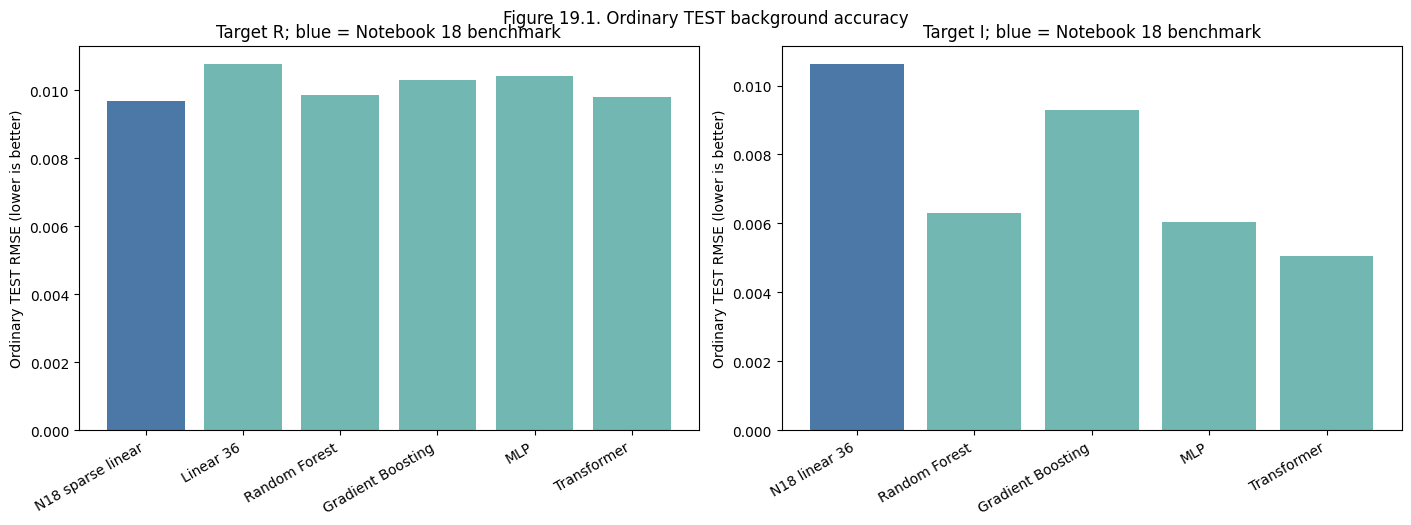

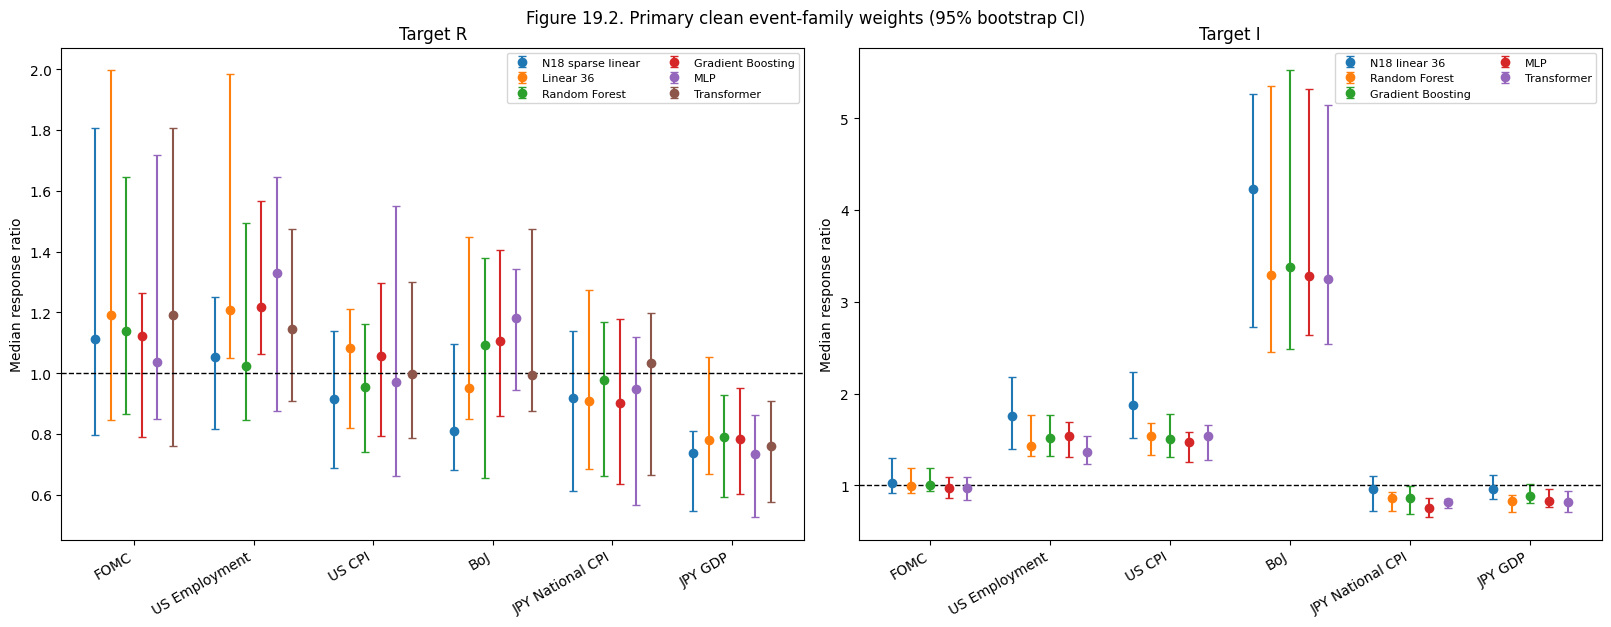

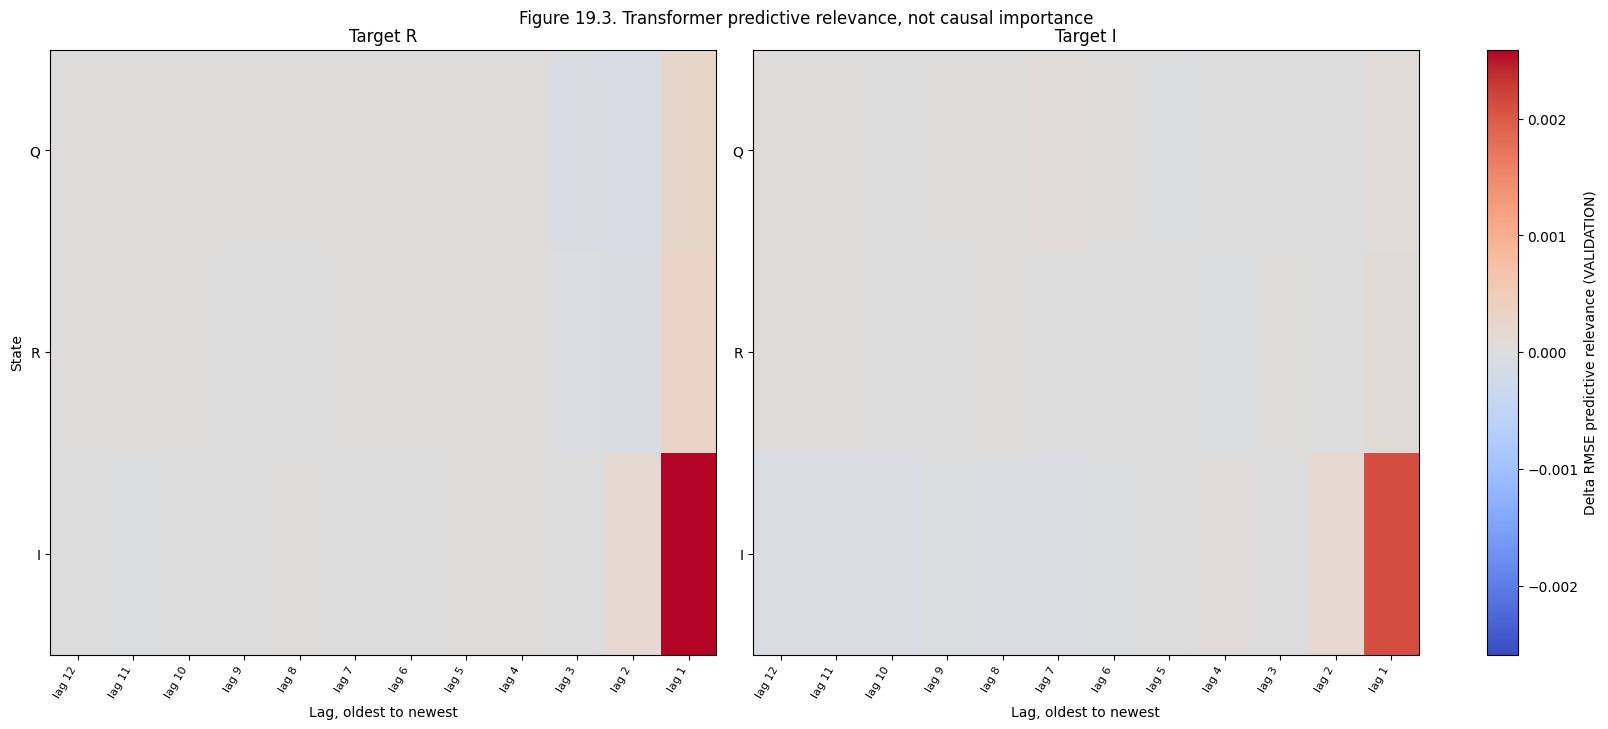

In [21]:
# PASS 3 figures (exactly three): TEST RMSE, primary pooled ratios, Transformer relevance.
import matplotlib.pyplot as plt
figure_output_dir = ROOT / "figures"; write_figures = figure_output_dir.is_dir()
model_labels = {"N18_SPARSE_LINEAR": "N18 sparse linear", "N18_LINEAR36": "N18 linear 36", "LINEAR_36": "Linear 36", "RANDOM_FOREST": "Random Forest", "GRADIENT_BOOSTING": "Gradient Boosting", "MLP": "MLP", "TRANSFORMER": "Transformer"}
rmse_column = "RMSE" if "RMSE" in ordinary_test_background_diagnostics.columns else "rmse"
# Figure 19.1: existing ordinary TEST diagnostics; lower is better.
figure_19_1, axes_19_1 = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, target in zip(axes_19_1, "RI"):
    plot = ordinary_test_background_diagnostics.loc[ordinary_test_background_diagnostics["target"].eq(target)].copy()
    plot["order"] = plot["model"].map({m: i for i, m in enumerate(TEST_MODEL_SETS[target])}); plot = plot.sort_values("order")
    ax.bar(range(len(plot)), plot[rmse_column], color=["#4C78A8" if m == N18_BENCHMARK_BY_TARGET[target] else "#72B7B2" for m in plot["model"]])
    ax.set_xticks(range(len(plot)), [model_labels[m] for m in plot["model"]], rotation=30, ha="right"); ax.set_ylabel("Ordinary TEST RMSE (lower is better)"); ax.set_title(f"Target {target}; blue = Notebook 18 benchmark"); ax.set_ylim(bottom=0)
figure_19_1.suptitle("Figure 19.1. Ordinary TEST background accuracy", y=1.02)
if write_figures: figure_19_1.savefig(figure_output_dir / "19_figure_19_1_ordinary_test_rmse.png", dpi=200, bbox_inches="tight")
plt.show()
# Figure 19.2: primary clean single-family pooled medians and percentile bootstrap CIs.
figure_19_2, axes_19_2 = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for ax, target in zip(axes_19_2, "RI"):
    plot = pooled_event_weights.loc[pooled_event_weights["target"].eq(target) & pooled_event_weights["pooling_sample"].eq(POOLING_SAMPLES["primary"])]
    families = [f for f in FROZEN_EVENT_FAMILIES if f in set(plot["family"])]; models = TEST_MODEL_SETS[target]; width = .78 / len(models); x = np.arange(len(families))
    for j, model in enumerate(models):
        rows = plot.loc[plot["model"].eq(model)].set_index("family").reindex(families); center = rows["median"].to_numpy(float)
        low = np.maximum(center - rows["median_ci_low"].to_numpy(float), 0); high = np.maximum(rows["median_ci_high"].to_numpy(float) - center, 0)
        ax.errorbar(x + (j - (len(models)-1)/2)*width, center, yerr=np.vstack([low, high]), fmt="o", capsize=3, label=model_labels[model])
    ax.axhline(1, color="black", linewidth=1, linestyle="--"); ax.set_xticks(x, families, rotation=30, ha="right"); ax.set_ylabel("Median response ratio"); ax.set_title(f"Target {target}"); ax.legend(fontsize=8, ncol=2)
figure_19_2.suptitle("Figure 19.2. Primary clean event-family weights (95% bootstrap CI)", y=1.02)
if write_figures: figure_19_2.savefig(figure_output_dir / "19_figure_19_2_event_weight_robustness.png", dpi=200, bbox_inches="tight")
plt.show()
# Figure 19.3: precomputed VALIDATION Transformer predictive relevance; not causal importance.
figure_19_3, axes_19_3 = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
values = np.concatenate([m.to_numpy(float).ravel() for m in transformer_individual_importance_matrices.values()]); limit = max(float(np.nanmax(np.abs(values))), 1e-12)
for ax, target in zip(axes_19_3, "RI"):
    matrix = transformer_individual_importance_matrices[target].reindex(index=["Q", "R", "I"], columns=list(range(12,0,-1)))
    image_19_3 = ax.imshow(matrix.to_numpy(float), aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.set_xticks(np.arange(12), [f"lag {lag}" for lag in range(12,0,-1)], rotation=60, ha="right", fontsize=8); ax.set_yticks(np.arange(3), ["Q", "R", "I"]); ax.set_xlabel("Lag, oldest to newest"); ax.set_title(f"Target {target}")
axes_19_3[0].set_ylabel("State"); figure_19_3.colorbar(image_19_3, ax=axes_19_3, label="Delta RMSE predictive relevance (VALIDATION)")
figure_19_3.suptitle("Figure 19.3. Transformer predictive relevance, not causal importance", y=1.02)
if write_figures: figure_19_3.savefig(figure_output_dir / "19_figure_19_3_transformer_predictive_relevance.png", dpi=200, bbox_inches="tight")
plt.show()


## Z. Final results, ordinary ratio distributions, exports, and audit

VALIDATION ordinary response-ratio distributions are exported for later Notebook 21 discovery calibration; TEST ordinary distributions are final OOS diagnostics only. Neither changes the raw event-weight definition.

In [22]:
# Final descriptive summaries, ordinary response ratios, exports, and realised-branch regression audit.
sensitivity_records = []
for (target, family), group in pooled_event_weights.loc[pooled_event_weights["pooling_sample"].eq(POOLING_SAMPLES["primary"])].groupby(["target", "family"]):
    medians = group["median"].to_numpy(float); finite = medians[np.isfinite(medians)]; positive = finite[finite > 0]
    sensitivity_records.append({
        "target": target, "family": family, "n_compared_models": len(medians),
        "cross_model_min_median": float(np.min(finite)) if len(finite) else np.nan,
        "cross_model_max_median": float(np.max(finite)) if len(finite) else np.nan,
        "cross_model_log_spread": float(np.max(np.log(positive)) - np.min(np.log(positive))) if len(positive) == len(finite) and len(positive) else np.nan,
        "all_model_medians_same_side_of_one": bool(len(finite) == len(medians) and len(finite) and len(np.unique(_side_of_one(finite))) == 1),
    })
primary_model_sensitivity_by_family = pd.DataFrame(sensitivity_records)
model_sensitivity_target_summary = primary_model_sensitivity_by_family.groupby("target", as_index=False).agg(
    n_families=("family", "nunique"), n_directionally_consistent_families=("all_model_medians_same_side_of_one", "sum"),
    directionally_consistent_family_fraction=("all_model_medians_same_side_of_one", "mean"),
    median_cross_model_log_spread=("cross_model_log_spread", "median"), maximum_cross_model_log_spread=("cross_model_log_spread", "max"),
)
agreement_target_summary = event_weight_agreement.groupby("target", as_index=False).agg(
    median_pairwise_same_side_of_one_fraction_vs_N18=("same_side_of_one_fraction", "median"),
    median_pairwise_absolute_log_ratio_difference_vs_N18=("median_absolute_log_ratio_difference", "median"),
)
model_sensitivity_target_summary = model_sensitivity_target_summary.merge(agreement_target_summary, on="target", how="left", validate="one_to_one")
best_test_models = ordinary_test_background_diagnostics.loc[
    ordinary_test_background_diagnostics.groupby("target")["RMSE"].idxmin(),
    ["target", "model", "RMSE", "R2_rel_N18"],
].rename(columns={"model": "lowest_ordinary_test_rmse_model", "RMSE": "lowest_ordinary_test_rmse"}).sort_values("target").reset_index(drop=True)

# Validation forecasts use frozen TRAIN objects. All records carry target-specific ordinary metadata.
validation_forecast_rows = []
for target, models in TEST_MODEL_SETS.items():
    frame = validation_frames[target]
    dates = frame[["model_day"]]
    benchmark = N18_BENCHMARK_BY_TARGET[target]
    assert frame["sample_split"].eq("validation").all()
    n18_validation = n18_forecasts.loc[
        n18_forecasts["target"].eq(target) & n18_forecasts["sample_split"].eq("validation"),
        ["model_day", "actual", "raw_background_forecast"],
    ]
    n18_validation = dates.merge(n18_validation, on="model_day", how="left", validate="one_to_one")
    assert n18_validation["raw_background_forecast"].notna().all()
    assert np.allclose(n18_validation["actual"], frame[target])
    predictions = {benchmark: n18_validation["raw_background_forecast"].to_numpy(float)}
    if target == "R":
        predictions["LINEAR_36"] = np.asarray(linear_predictions["R"], dtype=float)
    feature_values = frame[FEATURES].to_numpy(float)
    for model in ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]:
        predictions[model] = validation_prediction(target, model, feature_values)
    assert set(predictions) == set(models)
    for model, prediction in predictions.items():
        for row, value in zip(frame.itertuples(index=False), prediction):
            validation_forecast_rows.append({
                "model_day": row.model_day, "target_model_day": row.model_day,
                "model_day_role": "TARGET_SPECIFIC_RESPONSE_DAY", "sample_split": "validation", "split": "validation",
                "forecast_stage": "validation_oos_background", "is_out_of_sample": True,
                "target": target, "model": model, "actual": getattr(row, target), "background_forecast": float(value),
                "is_target_event_day": False, "is_clean_single_family": False, "is_overlap": False,
                "n_target_occurrences": 0, "n_target_families": 0, "family_set": "",
            })
validation_forecasts_export = pd.DataFrame(validation_forecast_rows)
for target, models in TEST_MODEL_SETS.items():
    expected_dates = set(validation_frames[target]["model_day"])
    rows = validation_forecasts_export.loc[validation_forecasts_export["target"].eq(target)]
    assert all(set(rows.loc[rows["model"].eq(model), "target_model_day"]) == expected_dates for model in models)

ordinary_response_ratios = pd.concat([
    validation_forecasts_export,
    test_background_forecasts.loc[~test_background_forecasts["is_target_event_day"]].copy(),
], ignore_index=True, sort=False)
ordinary_response_ratios = ordinary_response_ratios.loc[ordinary_response_ratios["sample_split"].isin(["validation", "test"])].copy()
ordinary_response_ratios["equation_eligible"] = ordinary_response_ratios["actual"].notna() & ordinary_response_ratios["background_forecast"].notna()
ordinary_response_ratios["background_positive"] = ordinary_response_ratios["equation_eligible"] & ordinary_response_ratios["background_forecast"].gt(0)
ordinary_response_ratios["ratio_defined"] = ordinary_response_ratios["equation_eligible"] & ordinary_response_ratios["background_positive"]
ordinary_response_ratios["response_ratio"] = np.where(ordinary_response_ratios["ratio_defined"], ordinary_response_ratios["actual"] / ordinary_response_ratios["background_forecast"], np.nan)
ordinary_response_ratios = ordinary_response_ratios[[
    "model_day", "target_model_day", "sample_split", "forecast_stage", "is_out_of_sample", "target", "model",
    "actual", "background_forecast", "equation_eligible", "background_positive", "ratio_defined", "response_ratio",
]]
ordinary_ratio_rows = []
for (split, target, model), group in ordinary_response_ratios.groupby(["sample_split", "target", "model"], sort=True):
    valid = group.loc[group["ratio_defined"], "response_ratio"].to_numpy(float)
    ordinary_ratio_rows.append({
        "sample_split": split, "target": target, "model": model,
        "n_eligible": int(group["equation_eligible"].sum()), "n_valid": int(len(valid)),
        "valid_fraction": len(valid) / len(group) if len(group) else np.nan,
        "mean": float(np.mean(valid)) if len(valid) else np.nan,
        "median": float(np.median(valid)) if len(valid) else np.nan,
        "q25": float(np.quantile(valid, .25)) if len(valid) else np.nan,
        "q75": float(np.quantile(valid, .75)) if len(valid) else np.nan,
    })
ordinary_response_ratio_summary = pd.DataFrame(ordinary_ratio_rows)
assert set(ordinary_response_ratios["sample_split"]) == {"validation", "test"}

# Regression check: realised masks and the realised branch should reproduce without forcing equality.
def max_abs_difference(left, right):
    values = np.abs(np.asarray(left, dtype=float) - np.asarray(right, dtype=float))
    values = values[np.isfinite(values)]
    return float(values.max()) if len(values) else np.nan

invariance_record = {
    "realised_target_event_mask_unchanged": True,
    "realised_train_eventless36_N": int(common_counts.loc[common_counts["target"].eq("R") & common_counts["split"].eq("train"), "eventless_36_N"].iloc[0]),
    "realised_validation_ordinary36_N": int(common_counts.loc[common_counts["target"].eq("R") & common_counts["split"].eq("validation"), "ordinary_evaluation_N"].iloc[0]),
    "selected_configs_match_prior": np.nan,
    "max_abs_test_background_difference": np.nan,
    "max_abs_event_weight_difference": np.nan,
}
if len(prior_selected_hyperparameters):
    old = prior_selected_hyperparameters.loc[prior_selected_hyperparameters["target"].eq("R"), ["model_family", "selected_config", "final_fixed_epochs"]]
    new = table_19_1.loc[table_19_1["target"].eq("R"), ["model_family", "selected_config", "final_fixed_epochs"]]
    compare = old.merge(new, on="model_family", suffixes=("_prior", "_current"), validate="one_to_one")
    invariance_record["selected_configs_match_prior"] = bool(compare["selected_config_prior"].eq(compare["selected_config_current"]).all() and np.allclose(compare["final_fixed_epochs_prior"].fillna(-1), compare["final_fixed_epochs_current"].fillna(-1)))
if len(prior_test_forecasts):
    old = prior_test_forecasts.loc[prior_test_forecasts["target"].eq("R"), ["model_day", "model", "background_forecast"]]
    new = test_background_forecasts.loc[test_background_forecasts["target"].eq("R"), ["model_day", "model", "background_forecast"]]
    compare = old.merge(new, on=["model_day", "model"], suffixes=("_prior", "_current"), validate="one_to_one")
    invariance_record["max_abs_test_background_difference"] = max_abs_difference(compare["background_forecast_prior"], compare["background_forecast_current"])
if len(prior_event_weights):
    old = prior_event_weights.loc[prior_event_weights["target"].eq("R"), ["family", "model_day", "model", "response_ratio"]]
    new = event_level_response_ratios.loc[event_level_response_ratios["target"].eq("R"), ["family", "model_day", "model", "response_ratio"]]
    compare = old.merge(new, on=["family", "model_day", "model"], suffixes=("_prior", "_current"), validate="one_to_one")
    invariance_record["max_abs_event_weight_difference"] = max_abs_difference(compare["response_ratio_prior"], compare["response_ratio_current"])
realised_invariance_audit = pd.DataFrame([invariance_record])

model_selection_validation_export = pd.concat([
    deterministic_selection.assign(selection_source="deterministic_validation"),
    neural_summary.assign(selection_source="neural_seed_validation"),
], ignore_index=True, sort=False)
selected_hyperparameters_export = table_19_1.copy()
neural_scalers_export = pd.concat([scaler_table, final_neural_scaler_table], ignore_index=True, sort=False).drop_duplicates()
feature_importance_validation_export = pd.concat([
    state_block_permutation_importance.assign(importance_scope="STATE_BLOCK"),
    lag_group_permutation_importance.assign(importance_scope="LAG_GROUP"),
    transformer_individual_feature_importance.assign(importance_scope="TRANSFORMER_INDIVIDUAL"),
], ignore_index=True, sort=False)

bounds = panel.groupby("sample_split")["model_day"].agg(["min", "max"])
def split_range(split):
    return f"{bounds.loc[split, 'min'].date()} to {bounds.loc[split, 'max'].date()}"

specification_rows = [
    ("DATA / INFORMATION SET", "states", "Q,R,I"), ("DATA / INFORMATION SET", "lag_count", "12"),
    ("DATA / INFORMATION SET", "feature_count", "36"), ("DATA / INFORMATION SET", "canonical_ordering", "oldest-to-newest"),
    ("DATA / INFORMATION SET", "lag_construction", "lags built before target-specific masking"),
    ("ALIGNMENT", "event_alignment_version", str(spec_18["event_alignment_version"])),
    ("ALIGNMENT", "event_alignment_source", "NOTEBOOK_18"),
    ("ALIGNMENT", "realised_event_day_field", "realised_model_day"),
    ("ALIGNMENT", "implied_event_day_field", "implied_model_day"),
    ("SPLITS", "TRAIN", split_range("train")), ("SPLITS", "VALIDATION", split_range("validation")), ("SPLITS", "TEST", split_range("test")),
    ("MODEL SET", "R_substantive_models", ", ".join(TEST_MODEL_SETS["R"])), ("MODEL SET", "I_substantive_models", ", ".join(TEST_MODEL_SETS["I"])),
    ("MODEL SET", "linear_implied_limitation", "N18 one-step benchmark; N18 stability diagnostic reported separately"),
    ("GRIDS", "RF_grid", str(RF_GRID)), ("GRIDS", "GB_grid", str(GB_GRID)), ("GRIDS", "MLP_grid", str(MLP_GRID)), ("GRIDS", "Transformer_grid", str(TR_GRID)),
    ("NEURAL PROTOCOL", "seeds", "19,119,219"), ("NEURAL PROTOCOL", "scaling", "statewise pooled-lag scaling"),
    ("NEURAL PROTOCOL", "validation_selection", "mean original-unit RMSE across three seeds"),
    ("FEATURE ATTRIBUTION", "interpretation", "predictive reliance, not causal importance"),
    ("EVENT WEIGHTS", "families", ", ".join(FROZEN_EVENT_FAMILIES)), ("EVENT WEIGHTS", "denominator", "strictly positive"),
    ("EVENT WEIGHTS", "repair", "no clipping, floor, or log repair"), ("EVENT WEIGHTS", "primary_sample", POOLING_SAMPLES["primary"]),
    ("EVENT WEIGHTS", "ordinary_ratio_role", "VALIDATION discovery calibration later; TEST final diagnostic only"),
    ("EVENT WEIGHTS", "bootstrap_repetitions", str(BOOTSTRAP_REPS)), ("EVENT WEIGHTS", "bootstrap_seed", str(BOOTSTRAP_SEED)),
    ("FREEZE", "DESIGN_FROZEN", str(DESIGN_FROZEN)),
    ("FREEZE", "TEST_restriction", "TEST does not select alignment, models, features, hyperparameters, epochs, or thresholds"),
]
primary_specification_export = pd.DataFrame(specification_rows, columns=["section", "item", "value"])

export_dir = ROOT / "Data" / "processed"
exports_19 = {
    "19_model_selection_validation.csv": model_selection_validation_export,
    "19_selected_hyperparameters.csv": selected_hyperparameters_export,
    "19_neural_seed_diagnostics.csv": neural_seed_diagnostics,
    "19_neural_scalers.csv": neural_scalers_export,
    "19_forecasts_validation.csv": validation_forecasts_export,
    "19_forecasts_test.csv": test_background_forecasts,
    "19_test_background_comparison.csv": ordinary_test_background_diagnostics,
    "19_positivity_audit.csv": raw_test_positivity_audit,
    "19_feature_importance_validation.csv": feature_importance_validation_export,
    "19_event_response_weights.csv": event_level_response_ratios,
    "19_pooled_event_weights.csv": pooled_event_weights,
    "19_event_weight_agreement.csv": event_weight_agreement,
    "19_ordinary_response_ratios.csv": ordinary_response_ratios,
    "19_ordinary_response_ratio_summary.csv": ordinary_response_ratio_summary,
    "19_realised_invariance_audit.csv": realised_invariance_audit,
    "19_primary_specification.csv": primary_specification_export,
}
for filename, table in exports_19.items():
    table.to_csv(export_dir / filename, index=False)
    assert len(pd.read_csv(export_dir / filename)) == len(table)
required_export_files = tuple(exports_19)
print("Ordinary TEST background winner(s):"); display(best_test_models)
print("Target-specific cross-model sensitivity:"); display(primary_model_sensitivity_by_family); display(model_sensitivity_target_summary)
print("Realised-branch regression audit:"); display(realised_invariance_audit)
print(f"Wrote {len(required_export_files)} Notebook 19 reproducibility CSVs.")

Ordinary TEST background winner(s):


,target,lowest_ordinary_test_rmse_model,lowest_ordinary_test_rmse,R2_rel_N18
0,I,TRANSFORMER,0.005061,0.773143
1,R,N18_SPARSE_LINEAR,0.009682,0.000000


Target-specific cross-model sensitivity:


,target,family,n_compared_models,cross_model_min_median,cross_model_max_median,cross_model_log_spread,all_model_medians_same_side_of_one
0,I,BoJ,5,3.247669,4.226137,0.263351,True
1,I,FOMC,5,0.971091,1.028432,0.057371,False
2,I,JPY GDP,5,0.817615,0.957446,0.157878,True
3,I,JPY National CPI,5,0.752361,0.956888,0.240470,True
4,I,US CPI,5,1.467969,1.878076,0.246368,True
5,I,US Employment,5,1.361494,1.754820,0.253784,True
6,R,BoJ,6,0.808312,1.182386,0.380342,False
7,R,FOMC,6,1.035634,1.192006,0.140624,True
8,R,JPY GDP,6,0.734701,0.790899,0.073706,True
9,R,JPY National CPI,6,0.901645,1.033202,0.136197,False


,target,n_families,n_directionally_consistent_families,directionally_consistent_family_fraction,median_cross_model_log_spread,maximum_cross_model_log_spread,median_pairwise_same_side_of_one_fraction_vs_N18,median_pairwise_absolute_log_ratio_difference_vs_N18
0,I,6,5,0.833333,0.243419,0.263351,0.801938,0.231651
1,R,6,3,0.500000,0.155008,0.380342,0.891253,0.175671


Realised-branch regression audit:


,realised_target_event_mask_unchanged,realised_train_eventless36_N,realised_validation_ordinary36_N,selected_configs_match_prior,max_abs_test_background_difference,max_abs_event_weight_difference
0,True,1683,834,True,1.006140e-16,1.421085e-14


Wrote 16 Notebook 19 reproducibility CSVs.


## AA. Final PASS 3 audit

This audit verifies the frozen model sets, target-specific benchmarks, complete pooling and agreement definitions, retained undefined rows, figures, and export bundle. It performs no fitting, selection, or feature-attribution calculation.

In [23]:
# Final target-specific audit: no fitting, reselection, or permutation recomputation occurs here.
assert DESIGN_FROZEN is True
assert len(TEST_MODEL_SETS["R"]) == 6 and len(TEST_MODEL_SETS["I"]) == 5
assert N18_BENCHMARK_BY_TARGET == {"R": "N18_SPARSE_LINEAR", "I": "N18_LINEAR36"}
assert all(N18_BENCHMARK_BY_TARGET[target] in TEST_MODEL_SETS[target] for target in "RI")
assert "LINEAR_36" not in TEST_MODEL_SETS["I"]
assert BOOTSTRAP_REPS == 10_000 and BOOTSTRAP_SEED == 19
assert tuple(FEATURES) == expected_feature_order and len(FEATURES) == 36
assert set(pooled_event_weights["pooling_sample"].unique()) == set(POOLING_SAMPLES.values())
assert pooled_event_weights["n_valid"].le(pooled_event_weights["n_sample_occurrences"]).all()
assert event_level_response_ratios.loc[~event_level_response_ratios["weight_defined"], "undefined_reason"].ne("").all()
assert event_level_response_ratios["sample_split"].eq("test").all()
assert event_level_response_ratios.loc[event_level_response_ratios["target"].eq("R"), "target_model_day"].eq(event_level_response_ratios.loc[event_level_response_ratios["target"].eq("R"), "realised_model_day"]).all()
assert event_level_response_ratios.loc[event_level_response_ratios["target"].eq("I"), "target_model_day"].eq(event_level_response_ratios.loc[event_level_response_ratios["target"].eq("I"), "implied_model_day"]).all()
assert set(event_weight_agreement["family"].unique()) == set(FROZEN_EVENT_FAMILIES)
assert not event_weight_agreement.duplicated(["target", "family", "comparator_model"]).any()
assert set(ordinary_response_ratio_summary["sample_split"]) == {"validation", "test"}
assert len(exports_19) == 16 and all((export_dir / name).exists() for name in required_export_files)
assert np.isfinite(transformer_individual_feature_summary["mean_delta_RMSE"]).all()
assert n18_stability.loc[0, "estimator_or_prediction_changed_by_diagnostic"] in {False, "False", "false"}
pass3_audit_status = pd.DataFrame([
    ("corrected_upstream", "N18 target-specific alignment contract inherited"),
    ("selection", "TRAIN fit and ordinary VALIDATION selection only"),
    ("test", "one final OOS evaluation; no TEST tuning"),
    ("event_weights", "target_model_day, strict positivity, raw denominator, undefined rows retained"),
    ("ordinary_ratios", "VALIDATION and TEST model-specific distributions exported separately"),
    ("importance", "VALIDATION predictive reliance only; not structural causality"),
    ("exports", f"{len(required_export_files)} required CSV files present"),
], columns=["check", "status"])
display(pass3_audit_status)

,check,status
0,corrected_upstream,N18 target-specific alignment contract inherited
1,selection,TRAIN fit and ordinary VALIDATION selection only
2,test,one final OOS evaluation; no TEST tuning
3,event_weights,"target_model_day, strict positivity, raw denom..."
4,ordinary_ratios,VALIDATION and TEST model-specific distributio...
5,importance,VALIDATION predictive reliance only; not struc...
6,exports,16 required CSV files present


# NOTEBOOK 19 COMPLETE - FINAL EXECUTION FINISHED

Notebook 19 has completed its final top-to-bottom execution. PASS 1, PASS 2 and PASS 3 completed successfully, the final audit passed, and the required Notebook 19 outputs were written to Data/processed.